In [12]:
pip install geodatasets


Note: you may need to restart the kernel to use updated packages.


In [13]:
pip install cartopy


Note: you may need to restart the kernel to use updated packages.


In [14]:
pip install geopandas fiona


Note: you may need to restart the kernel to use updated packages.


In [40]:
import pandas as pd

df = pd.read_csv('../../../inputData/fireslist2012-2024.csv')

/var/folders/53/419gvyh13dzgnkd1zfn_g5jw0000gn/T/ipykernel_50834/2650406014.py:17: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  raw_sizes = pd.to_numeric(plot_df["BurnBndAc"], errors="ignore") if "BurnBndAc" in plot_df.columns else None


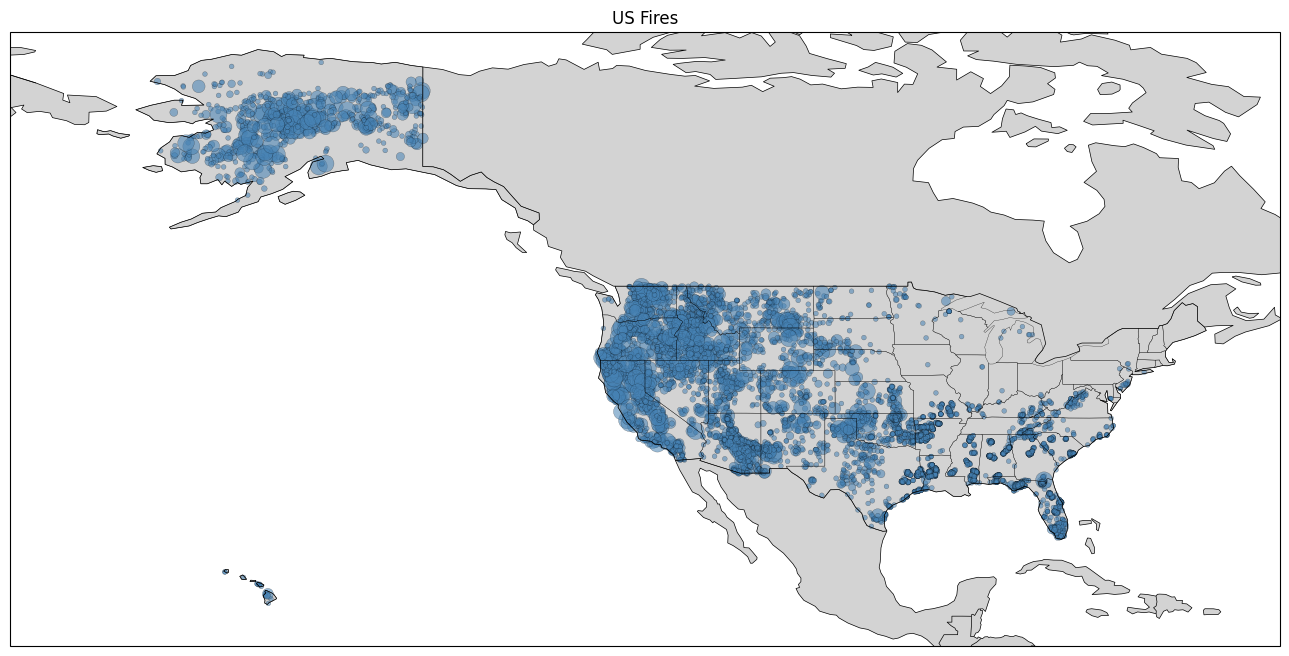

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

df["lon_mid"] = (pd.to_numeric(df["lon0"], errors="coerce") + pd.to_numeric(df["lon1"], errors="coerce")) / 2.0
df["lat_mid"] = (pd.to_numeric(df["lat0"], errors="coerce") + pd.to_numeric(df["lat1"], errors="coerce")) / 2.0

lon = df["lon_mid"].to_numpy(copy=True)
lon = np.where(lon > 180, lon - 360, lon)
df["lon_mid"] = lon

valid = df["lon_mid"].between(-180, 180) & df["lat_mid"].between(-90, 90)
plot_df = df.loc[valid].copy()

raw_sizes = pd.to_numeric(plot_df["BurnBndAc"], errors="ignore") if "BurnBndAc" in plot_df.columns else None
if raw_sizes is None or not np.issubdtype(raw_sizes.dtype, np.number):
    sizes = np.full(len(plot_df), 20.0)  # constant if area missing
else:
    s = raw_sizes.clip(lower=0)
    lo, hi = s.quantile(0.02), s.quantile(0.98)
    s = s.clip(lower=lo, upper=hi)
    sizes = (s / (hi if hi > 0 else 1.0)) * 150.0
    sizes = np.maximum(sizes, 12.0) # min visible size

fig = plt.figure(figsize=(13, 6.8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-180, -60, 15, 73], crs=ccrs.PlateCarree())

# Basemap
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
try:
    ax.add_feature(cfeature.STATES, linewidth=0.2)
except Exception:
    pass

ax.scatter(
    plot_df["lon_mid"], plot_df["lat_mid"],
    s=sizes, alpha=0.55, color="steelblue",
    linewidths=0.2, edgecolors="black",
    transform=ccrs.PlateCarree()
)

ax.set_title("US Fires")
plt.tight_layout()
plt.show()


Fires with valid size ≥ 4 km²: 7739


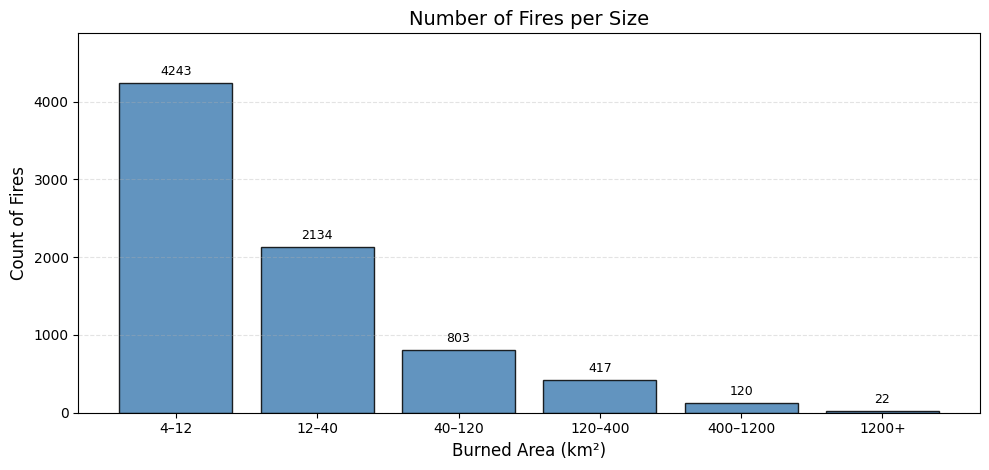

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TARGET_YEAR = None
data = df.copy()
if TARGET_YEAR is not None and "Year" in data.columns:
    data = data[data["Year"] == TARGET_YEAR]

if "BurnBndAc" in data.columns:
    # acres to km²
    sizes_km2 = pd.to_numeric(data["BurnBndAc"], errors="coerce") * 0.00404686
else:
    # rough bbox area estimate (only used if BurnBndAc absent)
    lat_mid = (pd.to_numeric(data["lat0"], errors="coerce") + pd.to_numeric(data["lat1"], errors="coerce")) / 2
    dlat = (pd.to_numeric(data["lat1"], errors="coerce") - pd.to_numeric(data["lat0"], errors="coerce")).abs()
    dlon = (pd.to_numeric(data["lon1"], errors="coerce") - pd.to_numeric(data["lon0"], errors="coerce")).abs()
    km_per_deg_lat = 111.32
    km_per_deg_lon = 111.32 * np.cos(np.deg2rad(lat_mid))
    sizes_km2 = dlat * km_per_deg_lat * dlon * km_per_deg_lon

sizes_km2 = sizes_km2.replace([np.inf, -np.inf], np.nan).dropna()
sizes_km2 = sizes_km2[sizes_km2 >= 4]

print(f"Fires with valid size ≥ 4 km²: {len(sizes_km2)}")
if len(sizes_km2) == 0:
    raise SystemExit("No valid sizes ≥ 4 km² to plot.")

bins   = [4, 12, 40, 120, 400, 1200, np.inf]
labels = ["4–12", "12–40", "40–120", "120–400", "400–1200", "1200+"]

cats = pd.cut(sizes_km2, bins=bins, labels=labels, right=False, include_lowest=True)
counts = cats.value_counts().reindex(labels, fill_value=0)

plt.figure(figsize=(10, 4.8))
bars = plt.bar(counts.index, counts.values, color="steelblue",
               edgecolor="black", alpha=0.85)

ymax = counts.values.max()
plt.ylim(0, ymax * 1.15)

# value labels
for i, c in enumerate(counts.values):
    plt.text(i, c + ymax * 0.015, str(int(c)),
             ha='center', va='bottom', fontsize=9)

# styling
plt.title("Number of Fires per Size", fontsize=14)
plt.xlabel("Burned Area (km²)", fontsize=12)
plt.ylabel("Count of Fires", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()


Number of fires with valid duration: 7739
Median duration: 1.44 days


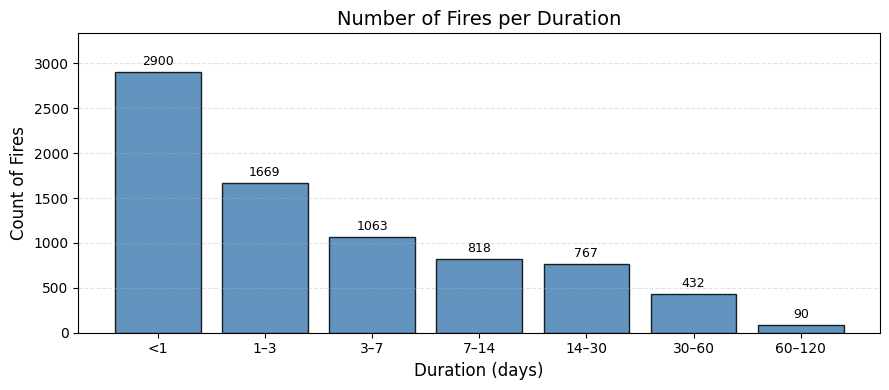

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

tst_dt = pd.to_datetime(df["tst"], errors="coerce")
ted_dt = pd.to_datetime(df["ted"], errors="coerce")

# start time default to 1:30 AM
tst_dt = tst_dt.dt.floor("D") + pd.Timedelta(hours=1, minutes=30)

dur_days = (ted_dt - tst_dt).dt.total_seconds() / 86400.0
dur_days = dur_days.replace([np.inf, -np.inf], np.nan).dropna()
dur_days = dur_days[dur_days >= 0]

print(f"Number of fires with valid duration: {len(dur_days)}")
print(f"Median duration: {dur_days.median():.2f} days")

bins   = [0, 1, 3, 7, 14, 30, 60, 120]  # upper bound = 120
labels = ["<1", "1–3", "3–7", "7–14", "14–30", "30–60", "60–120"]

cats = pd.cut(dur_days, bins=bins, labels=labels, right=False, include_lowest=True)
counts = cats.value_counts().reindex(labels, fill_value=0)

plt.figure(figsize=(9, 4))
bars = plt.bar(counts.index, counts.values, color="steelblue", edgecolor="black", alpha=0.85)

plt.ylim(0, max(counts.values) * 1.15)

for i, c in enumerate(counts.values):
    plt.text(i, c + max(counts.values)*0.015, str(int(c)),
             ha='center', va='bottom', fontsize=9)

plt.title("Number of Fires per Duration", fontsize=14)
plt.xlabel("Duration (days)", fontsize=12)
plt.ylabel("Count of Fires", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.35)

plt.tight_layout()
plt.show()


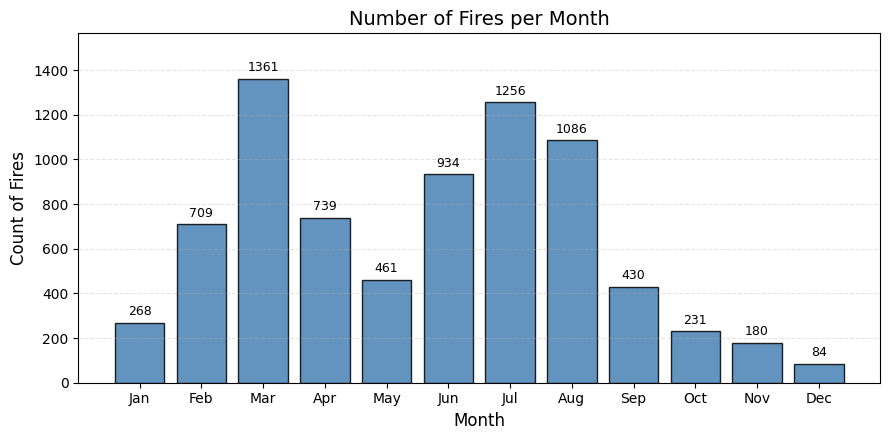

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

tst_dt = pd.to_datetime(df["tst"], errors="coerce")

tst_dt = tst_dt.dropna()

months = tst_dt.dt.month
month_names = tst_dt.dt.month_name().str[:3]

counts = months.value_counts().sort_index()
month_labels = [pd.to_datetime(str(m), format='%m').strftime('%b') for m in counts.index]

plt.figure(figsize=(9, 4.5))
bars = plt.bar(month_labels, counts.values, color="steelblue", edgecolor="black", alpha=0.85)

ymax = counts.values.max()
plt.ylim(0, ymax * 1.15)

for i, c in enumerate(counts.values):
    plt.text(i, c + ymax * 0.015, str(int(c)), ha="center", va="bottom", fontsize=9)

plt.title("Number of Fires per Month", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Count of Fires", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()



Per-fire summaries (for plotting):
                                  fire_id  mean_vpd  mean_precip_mm  avg_spread_rate_km2_per_hr    spread_start_utc      spread_end_utc  spread_duration_hr
    data_table_CA4054112256820200927_ZOGG  2.947108        0.000379                    0.867479 2020-09-28 08:00:00 2020-10-03 07:00:00               119.0
data_table_NJ3932007511020140424_RAILROAD  0.752429        0.000533                    0.000000 2014-04-24 05:00:00 2014-04-25 04:00:00                23.0
   data_table_CA3720111927220200905_CREEK  1.074312        0.032902                    1.138225 2020-09-05 09:00:00 2020-11-06 08:00:00              1487.0
   data_table_AZ3500811387920200817_RIDGE  3.352508        0.199025                    0.099832 2020-08-17 08:00:00 2020-08-22 07:00:00               119.0


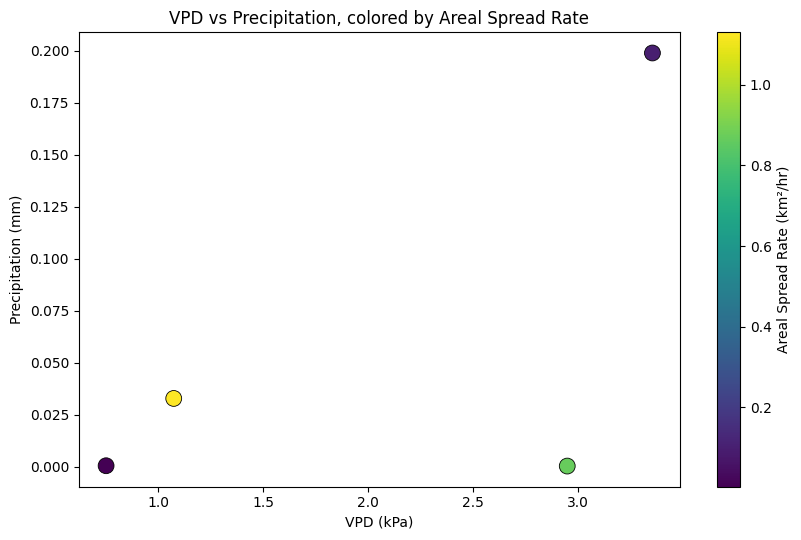

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

FILES = [
    "/Users/pc/Desktop/2025/FireCube/FireCube-1/output/sum_vis/CA4054112256820200927_ZOGG/data_table_CA4054112256820200927_ZOGG.csv",
    "/Users/pc/Desktop/2025/FireCube/FireCube-1/output/sum_vis/NJ3932007511020140424_RAILROAD/data_table_NJ3932007511020140424_RAILROAD.csv",
    "/Users/pc/Desktop/2025/FireCube/FireCube-1/output/sum_vis/CA3720111927220200905_CREEK/data_table_CA3720111927220200905_CREEK.csv",
    "/Users/pc/Desktop/2025/FireCube/FireCube-1/output/sum_vis/AZ3500811387920200817_RIDGE/data_table_AZ3500811387920200817_RIDGE.csv",
]

def summarize_fire_option1_exact(path: str) -> dict | None:
    """
      • Computes long-window average areal spread rate (km²/hr) from fperim/fline.
      • Trims NaNs, then removes first and last 24 h of valid data.
      • Uses that same time range to compute mean VPD and mean precipitation.
      • Records the actual UTC time window used.
    """
    df = pd.read_csv(path, sep="\t")

    for col in ["UTC", "vpd", "tp"]:
        if col not in df.columns:
            print(f"[WARN] {Path(path).name}: missing required column {col!r}; skipping.")
            return None

    area_col = (
        "fperim_area_km2"
        if "fperim_area_km2" in df.columns
        else ("fline_area_km2" if "fline_area_km2" in df.columns else None)
    )
    if area_col is None:
        print(f"[WARN] {Path(path).name}: no area column found; skipping.")
        return None

    df["UTC"] = pd.to_datetime(df["UTC"], errors="coerce")
    df = df.dropna(subset=["UTC"]).sort_values("UTC")
    df[area_col] = pd.to_numeric(df[area_col], errors="coerce")
    df["vpd"] = pd.to_numeric(df["vpd"], errors="coerce")
    df["tp"] = pd.to_numeric(df["tp"], errors="coerce")

    area_hr = (
        df[["UTC", area_col]]
        .set_index("UTC")
        .resample("1h")
        .mean()
        .ffill(limit=12)
    )

    if area_hr.empty:
        print(f"[WARN] {Path(path).name}: empty hourly area; skipping.")
        return None

    area_valid = area_hr.dropna(subset=[area_col])
    if area_valid.empty:
        print(f"[WARN] {Path(path).name}: no valid area values; skipping.")
        return None

    if len(area_valid) > 48:
        area_trim = area_valid.iloc[24:-24]
    else:
        area_trim = area_valid

    if area_trim.empty:
        print(f"[WARN] {Path(path).name}: trimmed area window empty; skipping.")
        return None

    A0, A1 = area_trim[area_col].iloc[[0, -1]]
    t0, t1 = area_trim.index[[0, -1]]
    dt_h = (t1 - t0).total_seconds() / 3600.0
    avg_spread = (A1 - A0) / dt_h if dt_h and dt_h > 0 else np.nan

    met_hr = (
        df[["UTC", "vpd", "tp"]]
        .set_index("UTC")
        .resample("1h")
        .mean()
        .interpolate("time", limit=6)
    )

    met_trim = met_hr.loc[t0:t1]
    mean_vpd = met_trim["vpd"].mean() if "vpd" in met_trim else np.nan
    mean_precip_mm = met_trim["tp"].mean() if "tp" in met_trim else np.nan

    return {
        "fire_id": Path(path).stem,
        "mean_vpd": mean_vpd,
        "mean_precip_mm": mean_precip_mm,
        "avg_spread_rate_km2_per_hr": avg_spread,
        "spread_start_utc": t0,
        "spread_end_utc": t1,
        "spread_duration_hr": dt_h,
    }

rows = []
for p in FILES:
    try:
        rec = summarize_fire_option1_exact(p)
        if rec is not None:
            rows.append(rec)
    except Exception as e:
        print(f"[ERROR] {Path(p).name}: {e}")

fires = pd.DataFrame(rows)

# Drop fires without met or spread for plotting
plot_df = fires.dropna(subset=["mean_vpd", "mean_precip_mm", "avg_spread_rate_km2_per_hr"]).copy()

print("\nPer-fire summaries (for plotting):")
print(plot_df.to_string(index=False))

if plot_df.empty:
    raise SystemExit("Nothing to plot: missing met variables or spread after trimming.")

vmin, vmax = np.nanpercentile(plot_df["avg_spread_rate_km2_per_hr"], [1, 99])

plt.figure(figsize=(8.5, 5.5))
sc = plt.scatter(
    plot_df["mean_vpd"],
    plot_df["mean_precip_mm"],
    c=plot_df["avg_spread_rate_km2_per_hr"],
    vmin=vmin, vmax=vmax,
    s=130, edgecolors="black", linewidths=0.6
)
plt.xlabel("VPD (kPa)")
plt.ylabel("Precipitation (mm)")
plt.title("VPD vs Precipitation, colored by Areal Spread Rate")
cbar = plt.colorbar(sc)
cbar.set_label("Areal Spread Rate (km²/hr)")
plt.tight_layout()
plt.show()


                                     fire_id    spread_start_utc  \
0      data_table_CA4054112256820200927_ZOGG 2020-09-28 08:00:00   
1  data_table_NJ3932007511020140424_RAILROAD 2014-04-24 05:00:00   
2     data_table_CA3720111927220200905_CREEK 2020-09-05 09:00:00   
3     data_table_AZ3500811387920200817_RIDGE 2020-08-17 08:00:00   

       spread_end_utc  duration_hr  
0 2020-10-03 07:00:00        119.0  
1 2014-04-25 04:00:00         23.0  
2 2020-11-06 08:00:00       1487.0  
3 2020-08-22 07:00:00        119.0  


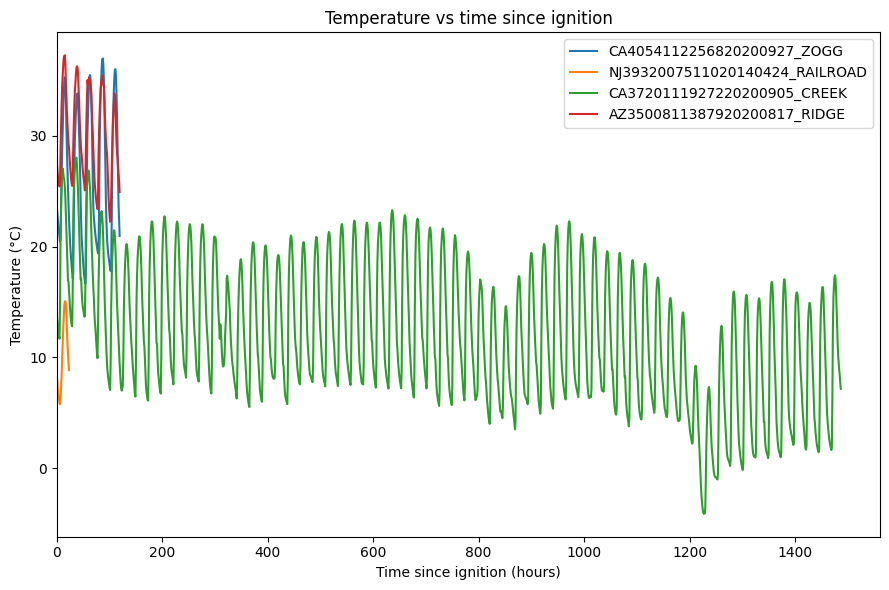

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

FILES = [
    "/Users/pc/Desktop/2025/FireCube/FireCube-1/output/sum_vis/CA4054112256820200927_ZOGG/data_table_CA4054112256820200927_ZOGG.csv",
    "/Users/pc/Desktop/2025/FireCube/FireCube-1/output/sum_vis/NJ3932007511020140424_RAILROAD/data_table_NJ3932007511020140424_RAILROAD.csv",
    "/Users/pc/Desktop/2025/FireCube/FireCube-1/output/sum_vis/CA3720111927220200905_CREEK/data_table_CA3720111927220200905_CREEK.csv",
    "/Users/pc/Desktop/2025/FireCube/FireCube-1/output/sum_vis/AZ3500811387920200817_RIDGE/data_table_AZ3500811387920200817_RIDGE.csv",
]

def get_temperature_series(path):
    df = pd.read_csv(path, sep="\t")
    df["UTC"] = pd.to_datetime(df["UTC"], errors="coerce")
    df = df.dropna(subset=["UTC"]).sort_values("UTC")

    area_col = "fperim_area_km2" if "fperim_area_km2" in df.columns else (
               "fline_area_km2" if "fline_area_km2" in df.columns else None)
    if area_col is None:
        print(f"[WARN] {Path(path).stem}: no area column; skipping.")
        return None

    if "t2m" not in df.columns:
        print(f"[WARN] {Path(path).stem}: missing 't2m'; skipping.")
        return None

    # numeric conversions
    df[area_col] = pd.to_numeric(df[area_col], errors="coerce")
    df["t2m"] = pd.to_numeric(df["t2m"], errors="coerce")

    # hourly resamples
    area_hr = df.set_index("UTC")[[area_col]].resample("1h").mean().ffill(limit=12)
    temp_hr = df.set_index("UTC")[["t2m"]].resample("1h").mean().interpolate("time", limit=6)

    area_valid = area_hr.dropna(subset=[area_col])
    if area_valid.empty:
        print(f"[WARN] {Path(path).stem}: no valid area after NaN trim; skipping.")
        return None
    area_trim = area_valid.iloc[24:-24] if len(area_valid) > 48 else area_valid
    if area_trim.empty:
        print(f"[WARN] {Path(path).stem}: empty after padding trim; skipping.")
        return None

    t0, t1 = area_trim.index[[0, -1]]
    temp_trim = temp_hr.loc[t0:t1]

    time_since_ignition = (temp_trim.index - t0).total_seconds() / 3600.0

    return {
        "name": Path(path).stem,
        "t": time_since_ignition,
        "temp": temp_trim["t2m"].values,
        "t0": t0,
        "t1": t1,
        "hours": (t1 - t0).total_seconds() / 3600.0,
    }

series = []
rows = []
for p in FILES:
    rec = get_temperature_series(p)
    if rec:
        series.append(rec)
        rows.append({
            "fire_id": rec["name"],
            "spread_start_utc": rec["t0"],
            "spread_end_utc": rec["t1"],
            "duration_hr": rec["hours"],
        })

if rows:
    print(pd.DataFrame(rows))

# plot
plt.figure(figsize=(9, 6))
for rec in series:
    label = rec["name"].replace("data_table_", "").replace(".csv", "")
    plt.plot(rec["t"], rec["temp"], label=label)

plt.xlim(left=0)
plt.xlabel("Time since ignition (hours)")
plt.ylabel("Temperature (°C)")
plt.title("Temperature vs time since ignition")
plt.legend()
plt.tight_layout()
plt.show()


In [22]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from pathlib import Path
from collections import Counter

FILES = [
    "/Users/pc/Desktop/2025/FireCube/FireCube-1/output/sum_vis/CA4054112256820200927_ZOGG/data_table_CA4054112256820200927_ZOGG.csv",
    "/Users/pc/Desktop/2025/FireCube/FireCube-1/output/sum_vis/NJ3932007511020140424_RAILROAD/data_table_NJ3932007511020140424_RAILROAD.csv",
    "/Users/pc/Desktop/2025/FireCube/FireCube-1/output/sum_vis/CA3720111927220200905_CREEK/data_table_CA3720111927220200905_CREEK.csv",
    "/Users/pc/Desktop/2025/FireCube/FireCube-1/output/sum_vis/AZ3500811387920200817_RIDGE/data_table_AZ3500811387920200817_RIDGE.csv",
]
CUBES_ROOT = Path("/Users/pc/Desktop/2025/FireCube/FireCube-1/output/cubes")
EVT_CROSSWALK = Path("/Users/pc/Desktop/2025/FireCube/FireCube-1/inputData/LF2024_EVT.csv")
MIN_PER_CATEGORY = 1
USE_LOG_Y = True
TRIM_PAD_HOURS = 24

def _extract_fid_from_csv_path(p: Path) -> str:
    stem = p.stem
    if stem.startswith("data_table_"):
        rest = stem[len("data_table_"):]
        return rest.split("_")[0]
    return p.parent.name.split("_")[0]

def _label_column_in_crosswalk(df_cross):
    for c in ["EVT_PHYS", "EVT_PHYSCL", "EVT_NAME", "EVT_LF"]:
        if c in df_cross.columns:
            return c
    raise ValueError("Crosswalk must contain one of: EVT_PHYS, EVT_PHYSCL, EVT_NAME, EVT_LF")

def _find_evt_tif(fid: str) -> Path | None:
    landfire_dir = CUBES_ROOT / fid / "landfire"
    p = landfire_dir / "200evt.tif"
    if p.exists():
        return p
    cands = sorted(landfire_dir.glob("*evt*.tif")) or sorted(landfire_dir.glob("*.tif"))
    return cands[0] if cands else None

def _find_fperim_tif(fid: str) -> Path | None:
    p = CUBES_ROOT / fid / "fire_spread" / "fperim.tif"
    return p if p.exists() else None

def _valid_window_indices(series_hourly: pd.Series, pad_hours: int) -> tuple[int, int]:
    """
    Given a 1H-resampled cumulative area series (NaNs already dropped), return
    inclusive band-span indices [lo_idx, hi_idx] after trimming first/last pad_hours.
    If too short, return the tightest possible window.
    """
    n = len(series_hourly)
    if n == 0:
        return 0, -1
    lo = min(pad_hours, max(0, n - 1))
    hi = max(lo, n - 1 - pad_hours)
    return lo, hi

def build_allowed_evt_codes(xwalk: pd.DataFrame, label_col: str) -> set[int]:
    """
    Return a set of EVT VALUE codes considered burnable vegetation.
    Excludes developed/roads/water/snow/quarries & pads.
    """
    if "VALUE" not in xwalk.columns:
        raise ValueError("Crosswalk must include a 'VALUE' column (EVT code).")

    exclude_regex = re.compile(
        r"(?:^|\b)"
        r"(Developed(?:-.+)?"
        r"|Roads"
        r"|Open\s*Water"
        r"|Snow[-– ]?Ice"
        r"|Quarries"
        r"|Strip\s*Mines"
        r"|Gravel\s*Pits"
        r"|Well\s*(?:and|&)\s*Wind\s*Pads)"
        r"(?:\b|$)",
        flags=re.IGNORECASE,
    )

    labels = xwalk[label_col].astype(str).fillna("")
    keep_mask = ~labels.str.contains(exclude_regex, na=False)
    allowed = set(xwalk.loc[keep_mask, "VALUE"].astype(int).tolist())
    return allowed

def _per_evt_spread_for_one_fire(fid: str, trim_pad_hours: int, crosswalk: pd.DataFrame, label_col: str) -> pd.DataFrame | None:
    fperim_tif = _find_fperim_tif(fid)
    evt_tif = _find_evt_tif(fid)
    if fperim_tif is None or evt_tif is None:
        return None

    HOURS_PER_STEP = 12
    PADDING_HOURS_EACH_SIDE = 24
    PAD_BANDS = PADDING_HOURS_EACH_SIDE // HOURS_PER_STEP

    with rasterio.open(evt_tif) as ds_evt:
        EVT = ds_evt.read(1)
        if ds_evt.nodata is not None:
            EVT = np.where(EVT == ds_evt.nodata, 0, EVT)

    allowed_codes = build_allowed_evt_codes(crosswalk, label_col)

    csv_guess = next((p for p in FILES if _extract_fid_from_csv_path(Path(p)) == fid), None)
    if csv_guess is None:
        return None
    df = pd.read_csv(csv_guess, sep="\t")
    if "UTC" not in df.columns:
        return None
    df["UTC"] = pd.to_datetime(df["UTC"], errors="coerce")
    df = df.dropna(subset=["UTC"]).sort_values("UTC")
    area_col = "fperim_area_km2" if "fperim_area_km2" in df.columns else ("fline_area_km2" if "fline_area_km2" in df.columns else None)
    if area_col is None:
        return None
    df[area_col] = pd.to_numeric(df[area_col], errors="coerce")

    area_hr = (df.set_index("UTC")[[area_col]].resample("1h").mean().ffill(limit=12)).dropna()
    if area_hr.empty:
        return None
    lo_idx, hi_idx = _valid_window_indices(area_hr[area_col], trim_pad_hours)
    area_trim = area_hr.iloc[lo_idx:hi_idx+1]
    if area_trim.empty or len(area_trim) < 2:
        return None

    hours_in_window = (area_trim.index[-1] - area_trim.index[0]).total_seconds() / 3600.0
    if hours_in_window <= 0:
        return None

    with rasterio.open(fperim_tif) as ds_fp:
        pix_km2 = abs(ds_fp.transform.a * ds_fp.transform.e) / 1e6
        B = ds_fp.count
        if B <= 2 * PAD_BANDS + 1:
            return None

        start_band = 1 + PAD_BANDS
        end_band   = B - PAD_BANDS

        acc = Counter()
        prev = (ds_fp.read(start_band) > 0)
        used_steps = 0
        for b in range(start_band + 1, end_band + 1):
            cur = (ds_fp.read(b) > 0)
            new = cur & (~prev)
            if new.any():
                codes, counts = np.unique(EVT[new], return_counts=True)
                for c, v in zip(codes, counts):
                    c = int(c)
                    if c > 0 and c in allowed_codes:
                        acc[c] += v * pix_km2
            prev = cur
            used_steps += 1

    if not acc or used_steps == 0:
        return None

    total_hours = hours_in_window

    out = pd.DataFrame({"VALUE": list(acc.keys()), "area_km2": list(acc.values())})
    out["rate_km2_hr"] = out["area_km2"] / float(total_hours)
    out = out.merge(crosswalk[["VALUE", label_col]], on="VALUE", how="left")
    out.rename(columns={label_col: "EVT_PHYS"}, inplace=True)
    out["fire_id"] = fid
    return out[["fire_id", "VALUE", "EVT_PHYS", "rate_km2_hr"]]

xwalk = pd.read_csv(EVT_CROSSWALK)
label_col = _label_column_in_crosswalk(xwalk)

all_rows = []
for f in FILES:
    fid = _extract_fid_from_csv_path(Path(f))
    df_evt = _per_evt_spread_for_one_fire(fid, TRIM_PAD_HOURS, xwalk, label_col)
    if df_evt is not None and not df_evt.empty:
        all_rows.append(df_evt)

if not all_rows:
    raise SystemExit("No per-EVT data to plot. Check fperim/EVT rasters and CSV columns.")

df_all = pd.concat(all_rows, ignore_index=True)
df_all = df_all.dropna(subset=["EVT_PHYS", "rate_km2_hr"])

counts = df_all.groupby("EVT_PHYS")["fire_id"].nunique()
keep_evt = counts[counts >= MIN_PER_CATEGORY].index
df_plot = df_all[df_all["EVT_PHYS"].isin(keep_evt)].copy()
if df_plot.empty:
    df_plot = df_all.copy()

order = (
    df_plot.groupby("EVT_PHYS")["rate_km2_hr"]
    .median()
    .sort_values(ascending=False)
    .index
    .tolist()
)
df_plot["EVT_PHYS"] = pd.Categorical(df_plot["EVT_PHYS"], categories=order, ordered=True)
df_plot = df_plot.sort_values("EVT_PHYS")

plt.figure(figsize=(12, 6))
groups = [g["rate_km2_hr"].values for _, g in df_plot.groupby("EVT_PHYS")]
positions = np.arange(1, len(groups) + 1)

bp = plt.boxplot(groups, positions=positions, widths=0.6, patch_artist=True, showfliers=False)
for b in bp["boxes"]:
    b.set(alpha=0.6)

labels = [evt for evt in df_plot["EVT_PHYS"].unique()]
plt.xticks(positions, labels, rotation=30, ha="right")

plt.ylabel("Areal spread rate (km²/hr)")
plt.title("Spread rate vs Fuel type")

if USE_LOG_Y:
    positive = df_plot["rate_km2_hr"][df_plot["rate_km2_hr"] > 0]
    if not positive.empty:
        plt.yscale("log")
        plt.ylim(bottom=max(1e-4, positive.min() * 0.5))
        plt.tick_params(axis="y", which="minor", length=0)

plt.grid(axis="y", linestyle=":", alpha=0.4)
plt.tight_layout()
plt.show()


/var/folders/53/419gvyh13dzgnkd1zfn_g5jw0000gn/T/ipykernel_50834/1800897774.py:82: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  keep_mask = ~labels.str.contains(exclude_regex, na=False)


IndexError: boolean index did not match indexed array along dimension 0; dimension is 1200 but corresponding boolean dimension is 120

                                     fire_id      elev_start_utc        elev_end_utc  duration_hr
0      data_table_CA4054112256820200927_ZOGG 2020-09-27 09:00:00 2020-10-03 08:00:00        143.0
1  data_table_NJ3932007511020140424_RAILROAD 2014-04-23 05:00:00 2014-04-25 04:00:00         47.0
2     data_table_CA3720111927220200905_CREEK 2020-09-04 09:00:00 2020-11-06 08:00:00       1511.0
3     data_table_AZ3500811387920200817_RIDGE 2020-08-16 08:00:00 2020-08-22 07:00:00        143.0


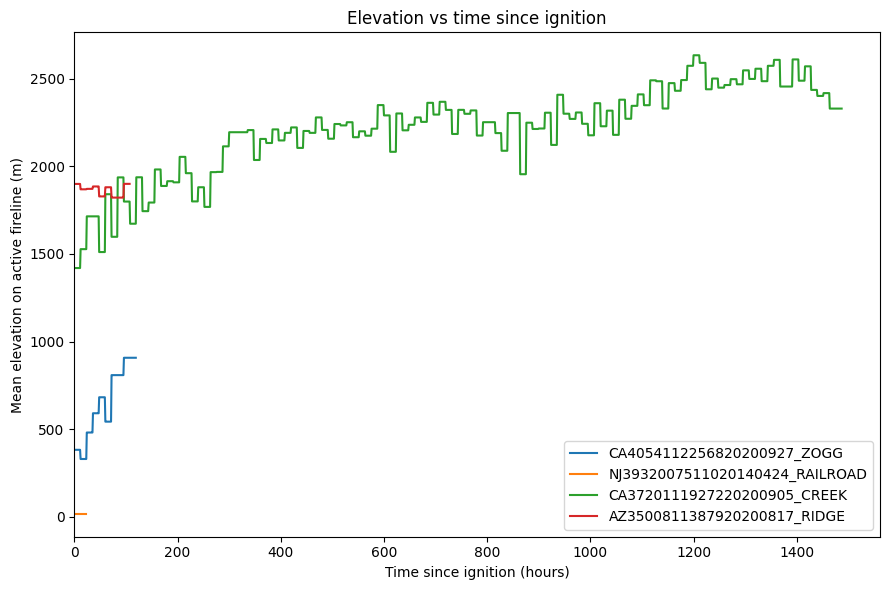

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

FILES = [
    "/Users/pc/Desktop/2025/FireCube/FireCube-1/output/sum_vis/CA4054112256820200927_ZOGG/data_table_CA4054112256820200927_ZOGG.csv",
    "/Users/pc/Desktop/2025/FireCube/FireCube-1/output/sum_vis/NJ3932007511020140424_RAILROAD/data_table_NJ3932007511020140424_RAILROAD.csv",
    "/Users/pc/Desktop/2025/FireCube/FireCube-1/output/sum_vis/CA3720111927220200905_CREEK/data_table_CA3720111927220200905_CREEK.csv",
    "/Users/pc/Desktop/2025/FireCube/FireCube-1/output/sum_vis/AZ3500811387920200817_RIDGE/data_table_AZ3500811387920200817_RIDGE.csv",
]

def get_elevation_series(path):
    df = pd.read_csv(path, sep="\t")
    df["UTC"] = pd.to_datetime(df["UTC"], errors="coerce")
    df = df.dropna(subset=["UTC"]).sort_values("UTC")

    area_col = "fperim_area_km2" if "fperim_area_km2" in df.columns else (
               "fline_area_km2" if "fline_area_km2" in df.columns else None)
    if area_col is None:
        print(f"[WARN] {Path(path).stem}: no area column; skipping.")
        return None

    elev_col = None
    if "fline_mean_elev_m" in df.columns:
        elev_col = "fline_mean_elev_m"
    elif "elev_mean" in df.columns:
        elev_col = "elev_mean"
    else:
        print(f"[WARN] {Path(path).stem}: missing elevation column ('fline_mean_elev_m' or 'elev_mean'); skipping.")
        return None

    df[area_col] = pd.to_numeric(df[area_col], errors="coerce")
    df[elev_col] = pd.to_numeric(df[elev_col], errors="coerce")

    area_hr = df.set_index("UTC")[[area_col]].resample("1h").mean().ffill(limit=12)
    elev_hr = df.set_index("UTC")[[elev_col]].resample("1h").mean().interpolate("time", limit=6)

    area_valid = area_hr.dropna(subset=[area_col])
    if area_valid.empty:
        print(f"[WARN] {Path(path).stem}: no valid area after NaN trim; skipping.")
        return None

    if len(area_valid) > 24:
        area_trim = area_valid.iloc[:-24]
    else:
        area_trim = area_valid

    if area_trim.empty:
        print(f"[WARN] {Path(path).stem}: empty after trimming last 24h; skipping.")
        return None

    t0, t1 = area_trim.index[[0, -1]]

    elev_window = elev_hr.loc[t0:t1].interpolate("time", limit=6)
    elev_valid  = elev_window.dropna(subset=[elev_col])

    if elev_valid.empty:
        print(f"[WARN] {Path(path).stem}: no non-NaN elevation in window; skipping.")
        return None

    t0_elev = elev_valid.index[0]

    elev_trim = elev_valid.reindex(pd.date_range(t0_elev, t1, freq="1h")).interpolate("time")

    time_since_ignition = (elev_trim.index - t0_elev).total_seconds() / 3600.0


    return {
        "name": Path(path).stem,
        "t": time_since_ignition,
        "elev": elev_trim[elev_col].values,
        "t0": t0,
        "t1": t1,
        "hours": (t1 - t0).total_seconds() / 3600.0,
    }

series = []
rows = []
for p in FILES:
    rec = get_elevation_series(p)
    if rec:
        series.append(rec)
        rows.append({
            "fire_id": rec["name"],
            "elev_start_utc": rec["t0"],
            "elev_end_utc": rec["t1"],
            "duration_hr": rec["hours"],
        })

if rows:
    print(pd.DataFrame(rows))

# plot
plt.figure(figsize=(9, 6))
for rec in series:
    label = rec["name"].replace("data_table_", "").replace(".csv", "")
    plt.plot(rec["t"], rec["elev"], label=label)

plt.xlim(left=0)
plt.xlabel("Time since ignition (hours)")
plt.ylabel("Mean elevation on active fireline (m)")
plt.title("Elevation vs time since ignition")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import os
from pathlib import Path
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def plot_fire_progress(cubes_dir, fid, n_steps=5):
    cubes_dir = Path(cubes_dir).resolve()
    fire_dir = cubes_dir / fid / "fire_spread"
    fperim_tif = fire_dir / "fperim.tif"

    if not fperim_tif.exists():
        raise FileNotFoundError(f"Missing {fperim_tif}")

    fperim_ds = rasterio.open(fperim_tif)
    n_bands = fperim_ds.count

    # 1) Find first active band (where fire appears)
    first_active = None
    for b in range(1, n_bands + 1):
        arr = fperim_ds.read(b)
        if np.any(arr > 0):
            first_active = b
            break
    if first_active is None:
        raise ValueError("Fire never appears in fperim.")

    # 2) Choose timesteps evenly from first_active -> last band
    raw = np.linspace(first_active, n_bands, n_steps)
    band_indices = sorted({int(round(x)) for x in raw})
    print("Using bands:", band_indices)

    # 3) Prepare figure and map extent
    fig, ax = plt.subplots(figsize=(10, 6))

    transform = fperim_ds.transform
    width, height = fperim_ds.width, fperim_ds.height
    extent = (
        transform.c,
        transform.c + transform.a * width,
        transform.f + transform.e * height,
        transform.f,
    )

    # 4) Colors for each timestep (light -> dark)
    cmap = plt.cm.Oranges
    colors = [cmap((i + 1) / (n_steps + 1)) for i in range(n_steps)]

    # 5) Plot *incremental* growth for each chosen timestep
    cumulative_mask = None
    for i, b in enumerate(band_indices):
        perim = fperim_ds.read(int(b))
        mask = perim > 0

        if cumulative_mask is None:
            # first timestep: all burned area is "new"
            new_growth = mask
            cumulative_mask = mask.copy()
        else:
            # only pixels that are newly burned compared to previous timesteps
            new_growth = mask & ~cumulative_mask
            cumulative_mask |= mask

        if not np.any(new_growth):
            continue  # nothing new in this step

        ax.imshow(
            np.ma.masked_where(~new_growth, new_growth),
            extent=extent,
            origin="upper",
            cmap=ListedColormap([colors[i]]),
            interpolation="nearest",
            alpha=0.9,   # quite visible
        )

    ax.set_title(
        f"Fire progression",
        fontsize=16,
    )

    plt.tight_layout()
    plt.show()

    fperim_ds.close()


Using bands: [25, 307, 588, 870, 1152]


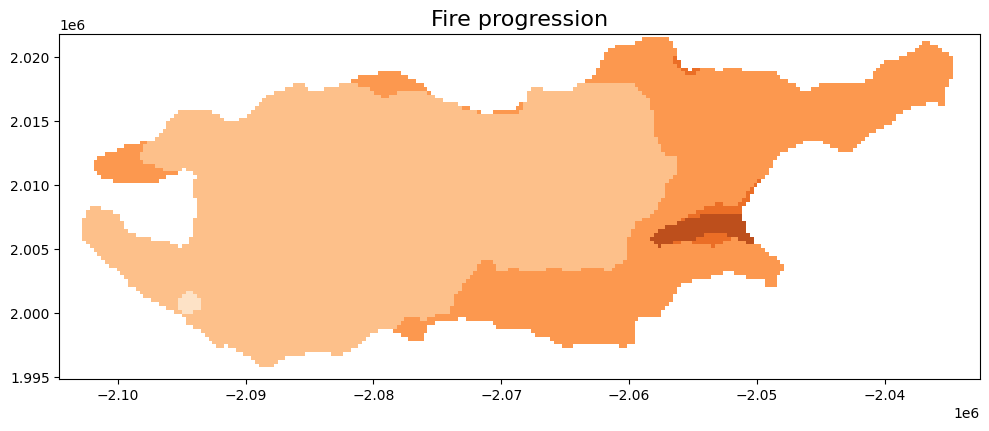

In [ ]:
plot_fire_progress(
    "/Users/pc/Desktop/2025/FireCube/FireCube-1/output/cubes",
    "CA3858612053820210815",
    n_steps=5
)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_burned_area_vs_fires_per_year(
    firelist_path="feds2.5_firelist.csv",
    area_col="BurnBndAc",
    year_col="Year",
    id_col="Event_ID",
):
    firelist = pd.read_csv(firelist_path)

    # Aggregate yearly stats
    yearly_stats = (
        firelist
        .groupby(year_col)
        .agg(
            total_burned_area_acres=(area_col, "sum"),
            fire_count=(id_col, "nunique"),
        )
        .reset_index()
        .sort_values(year_col)
    )

    # Convert acres -> km²
    yearly_stats["total_burned_area_km2"] = (
        yearly_stats["total_burned_area_acres"] * 0.00404686
    )

    years = yearly_stats[year_col]
    area_km2 = yearly_stats["total_burned_area_km2"]
    count = yearly_stats["fire_count"]

    # Plot
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # BLUE line → burned area (km²)
    line1 = ax1.plot(
        years, area_km2, color="red", marker="o",
        label="Total burned area (km²)"
    )
    ax1.set_xlabel("Year")
    ax1.set_ylabel("Total burned area (km²)")

    # RED bars → number of fires
    ax2 = ax1.twinx()
    bar_width = 0.6
    bars = ax2.bar(
        years, count, alpha=0.4, width=bar_width,
        label="Number of fires"
    )
    ax2.set_ylabel("Number of fires")

    # Legends combined
    ax1.legend(loc="upper left")
    ax2.legend(loc="upper right")

    plt.title("Burned Area vs Number of Fires per Year")
    plt.tight_layout()
    plt.show()

    pd.set_option("display.max_rows", None)
    
    return yearly_stats


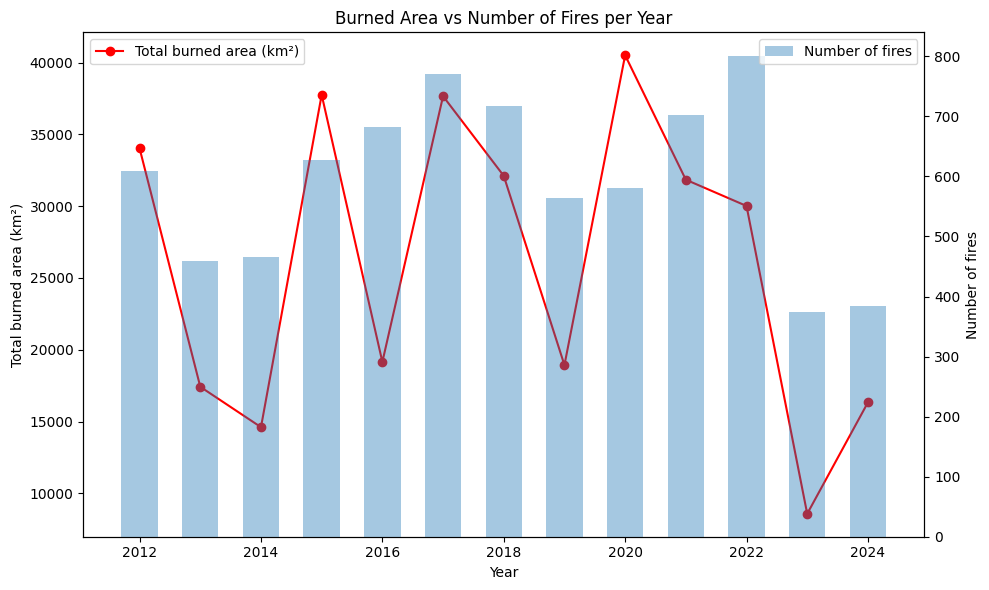

,Year,total_burned_area_acres,fire_count,total_burned_area_km2
0,2012,8407361,609,34023.412936
1,2013,4304283,460,17418.830701
2,2014,3610015,466,14609.225303
3,2015,9328774,628,37752.242350
4,2016,4732640,682,19152.331510
5,2017,9305528,770,37658.169042
6,2018,7934746,718,32110.806198
7,2019,4678548,564,18933.428759
8,2020,10009858,580,40508.493946
9,2021,7868411,702,31842.357739


In [ ]:
stats = plot_burned_area_vs_fires_per_year("/Users/pc/Desktop/2025/FireCube/FireCube-1/inputData/fireslist2012-2024.csv")
stats

Total cube folders: 158
Valid ignition elevations: 129
Cube folders with no matching Event_ID: 0
Cube folders with missing dem.tif: 0
Cube folders with zero-byte dem.tif: 0
Sample/read errors: 0
Nodata / invalid DEM values: 29


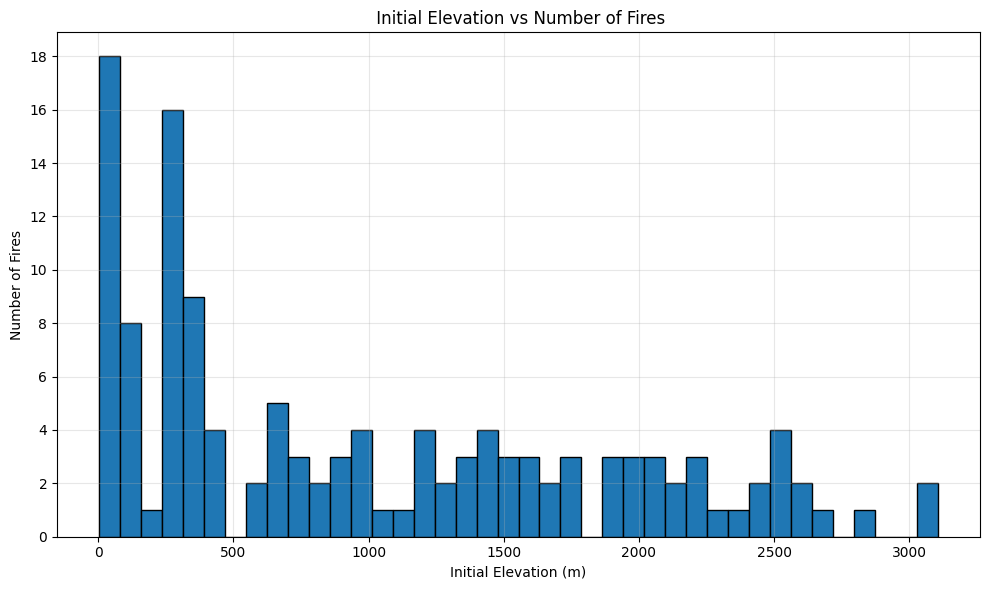


Elevation statistics (m):
Min     = 3.00
Max     = 3106.00
Mean    = 994.00
Median  = 717.00


In [3]:
%matplotlib inline

from pathlib import Path
import pandas as pd
import numpy as np
import rasterio
from rasterio.warp import transform
import matplotlib.pyplot as plt

def plot_initial_elevation_from_cubes(
    firelist_path="fireslist2012-2024.csv",
    cubes_root="output/cubes",
    fire_id_col="Event_ID",
    lon_col="lon0",
    lat_col="lat0",
    dem_relpath="fuel_topo/dem.tif",
    bins=40
):
    cubes_root = Path(cubes_root)
    df = pd.read_csv(firelist_path)

    for col in [fire_id_col, lon_col, lat_col]:
        if col not in df.columns:
            raise ValueError(f"Column '{col}' not found in firelist")

    df[fire_id_col] = df[fire_id_col].astype(str)
    id_lengths = df[fire_id_col].str.len()
    suffix_len = int(id_lengths.mode().iloc[0])

    id_to_coord = {}
    for _, row in df.iterrows():
        fid = str(row[fire_id_col])
        id_to_coord[fid] = (float(row[lon_col]), float(row[lat_col]))

    elevations = []
    missing_dem = 0
    zero_size_dem = 0
    cube_without_match = 0
    sample_errors = 0
    nodata_count = 0

    for d in cubes_root.iterdir():
        if not d.is_dir():
            continue
        name = d.name
        if len(name) < suffix_len:
            continue
        suffix = name[-suffix_len:]
        if suffix not in id_to_coord:
            cube_without_match += 1
            continue

        lon, lat = id_to_coord[suffix]
        dem_path = d / dem_relpath

        if not dem_path.is_file():
            missing_dem += 1
            continue
        if dem_path.stat().st_size == 0:
            zero_size_dem += 1
            continue

        try:
            with rasterio.open(dem_path) as src:
                src_crs = src.crs
                if src_crs is not None and src_crs.to_string() != "EPSG:4326":
                    xs, ys = transform("EPSG:4326", src_crs, [lon], [lat])
                    x, y = xs[0], ys[0]
                else:
                    x, y = lon, lat

                val = list(src.sample([(x, y)]))[0][0]

                if src.nodata is not None and val == src.nodata:
                    nodata_count += 1
                    continue
                if np.isnan(val):
                    nodata_count += 1
                    continue

                elevations.append(val)

        except Exception as e:
            print(f"Warning for cube {name}: {e}")
            sample_errors += 1
            continue

    elevations = np.array(elevations)

    print(f"Total cube folders: {len([d for d in cubes_root.iterdir() if d.is_dir()])}")
    print(f"Valid ignition elevations: {len(elevations)}")
    print(f"Cube folders with no matching Event_ID: {cube_without_match}")
    print(f"Cube folders with missing dem.tif: {missing_dem}")
    print(f"Cube folders with zero-byte dem.tif: {zero_size_dem}")
    print(f"Sample/read errors: {sample_errors}")
    print(f"Nodata / invalid DEM values: {nodata_count}")

    if elevations.size == 0:
        print("No valid ignition elevations collected.")
        return elevations

    plt.figure(figsize=(10, 6))
    plt.hist(elevations, bins=bins, edgecolor="black")
    plt.title(" Initial Elevation vs Number of Fires")
    plt.xlabel("Initial Elevation (m)")
    plt.ylabel("Number of Fires")
    from matplotlib.ticker import MaxNLocator
    plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("\nElevation statistics (m):")
    print(f"Min     = {elevations.min():.2f}")
    print(f"Max     = {elevations.max():.2f}")
    print(f"Mean    = {elevations.mean():.2f}")
    print(f"Median  = {np.median(elevations):.2f}")

    return elevations

elevations = plot_initial_elevation_from_cubes(
    firelist_path="/Users/pc/Desktop/2025/FireCube/FireCube-1/inputData/fireslist2012-2024.csv",
    cubes_root="/Users/pc/Desktop/2025/FireCube/FireCube-1/output/cubes",
)


Total cube folders: 158
Valid ignition elevations: 128
Cube folders with no matching Event_ID: 1
Cube folders with missing dem.tif: 0
Cube folders with zero-byte dem.tif: 0
Sample/read errors: 0
Nodata / invalid DEM values: 29


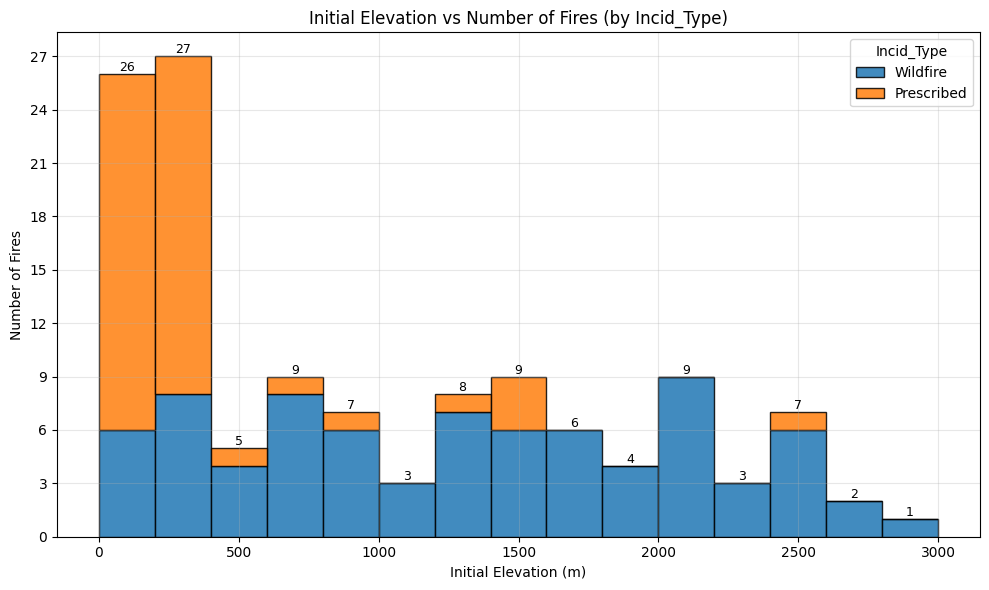


Elevation statistics (m):
Min     = 3.00
Max     = 3106.00
Mean    = 996.35
Median  = 739.50
                Event_ID  Incid_Type  elevation
0  FL2938708179720190220  Prescribed       15.0
1  FL3019208497920240226  Prescribed       19.0
2  AL3375808554020220201  Prescribed      390.0
3  CA4038712182320120818    Wildfire      699.0
4  TX3128009530020160316  Prescribed       97.0


In [ ]:
%matplotlib inline

from pathlib import Path
import pandas as pd
import numpy as np
import rasterio
from rasterio.warp import transform
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def plot_initial_elevation_from_cubes(
    firelist_path="/Users/pc/Desktop/2025/FireCube/FireCube-1/inputData/fireslist2012-2024_withtype.csv",
    cubes_root="/Users/pc/Desktop/2025/FireCube/FireCube-1/output/cubes",
    fire_id_col="Event_ID",
    lon_col="lon0",
    lat_col="lat0",
    incid_type_col="Incid_Type",
    dem_relpath="fuel_topo/dem.tif",
    elev_bins=None,                 # e.g. np.arange(0, 3200, 200)
    type_order=("Wildfire", "Prescribed"),
    type_colors=None,
    make_plot=True
):
    if type_colors is None:
        type_colors = {"Wildfire": "#1f77b4", "Prescribed": "#ff7f0e"}
    if elev_bins is None:
        elev_bins = np.arange(0, 3200, 200)

    cubes_root = Path(cubes_root)
    df = pd.read_csv(firelist_path)

    for col in [fire_id_col, lon_col, lat_col, incid_type_col]:
        if col not in df.columns:
            raise ValueError(f"Column '{col}' not found in firelist")

    # Normalize Incid_Type to exactly two categories
    df[incid_type_col] = (
        df[incid_type_col].astype(str).str.strip()
        .replace({"Prescribed Fire": "Prescribed", "Wildfire": "Wildfire"})
    )
    df = df[df[incid_type_col].isin(list(type_order))].copy()

    df[fire_id_col] = df[fire_id_col].astype(str)
    suffix_len = int(df[fire_id_col].str.len().mode().iloc[0])

    # Map Event_ID -> (lon, lat, Incid_Type)
    id_to_info = {
        str(row[fire_id_col]): (float(row[lon_col]), float(row[lat_col]), str(row[incid_type_col]))
        for _, row in df.iterrows()
    }

    rows = []
    missing_dem = 0
    zero_size_dem = 0
    cube_without_match = 0
    sample_errors = 0
    nodata_count = 0

    total_cube_folders = 0

    for d in cubes_root.iterdir():
        if not d.is_dir():
            continue
        total_cube_folders += 1

        name = d.name
        if len(name) < suffix_len:
            continue

        event_id = name[-suffix_len:]
        if event_id not in id_to_info:
            cube_without_match += 1
            continue

        lon, lat, incid_type = id_to_info[event_id]
        dem_path = d / dem_relpath

        if not dem_path.is_file():
            missing_dem += 1
            continue
        if dem_path.stat().st_size == 0:
            zero_size_dem += 1
            continue

        try:
            with rasterio.open(dem_path) as src:
                src_crs = src.crs
                if src_crs is not None and src_crs.to_string() != "EPSG:4326":
                    xs, ys = transform("EPSG:4326", src_crs, [lon], [lat])
                    x, y = xs[0], ys[0]
                else:
                    x, y = lon, lat

                val = list(src.sample([(x, y)]))[0][0]

                # nodata / invalid checks
                if (src.nodata is not None and val == src.nodata) or np.isnan(val):
                    nodata_count += 1
                    continue

                rows.append({
                    fire_id_col: event_id,
                    incid_type_col: incid_type,
                    "elevation": float(val)
                })

        except Exception as e:
            print(f"Warning for cube {name}: {e}")
            sample_errors += 1
            continue

    elev_df = pd.DataFrame(rows)

    print(f"Total cube folders: {total_cube_folders}")
    print(f"Valid ignition elevations: {len(elev_df)}")
    print(f"Cube folders with no matching Event_ID: {cube_without_match}")
    print(f"Cube folders with missing dem.tif: {missing_dem}")
    print(f"Cube folders with zero-byte dem.tif: {zero_size_dem}")
    print(f"Sample/read errors: {sample_errors}")
    print(f"Nodata / invalid DEM values: {nodata_count}")

    if elev_df.empty:
        print("No valid ignition elevations collected.")
        return elev_df

    if make_plot:
        w = elev_df.loc[elev_df[incid_type_col] == type_order[0], "elevation"].to_numpy()
        p = elev_df.loc[elev_df[incid_type_col] == type_order[1], "elevation"].to_numpy()

        # Explicit histograms (same idea as veg_counts_by_type)
        w_counts, bin_edges = np.histogram(w, bins=elev_bins)
        p_counts, _         = np.histogram(p, bins=elev_bins)

        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
        totals = w_counts + p_counts
        ymax = totals.max() if len(totals) else 0

        plt.figure(figsize=(10, 6))

        # Stacked bars
        plt.bar(
            bin_centers,
            w_counts,
            width=np.diff(bin_edges),
            edgecolor="black",
            alpha=0.85,
            color=type_colors[type_order[0]],
            label=type_order[0],
            align="center",
        )
        plt.bar(
            bin_centers,
            p_counts,
            width=np.diff(bin_edges),
            bottom=w_counts,
            edgecolor="black",
            alpha=0.85,
            color=type_colors[type_order[1]],
            label=type_order[1],
            align="center",
        )

        for x, total in zip(bin_centers, totals):
            if total > 0:
                plt.text(
                    x,
                    total,
                    str(int(total)),
                    ha="center",
                    va="bottom",
                    fontsize=9,
                )

        plt.title("Initial Elevation vs Number of Fires (by Incid_Type)")
        plt.xlabel("Initial Elevation (m)")
        plt.ylabel("Number of Fires")
        plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))
        plt.grid(True, alpha=0.3)
        plt.legend(title=incid_type_col)
        plt.tight_layout()
        plt.show()



    # Stats (overall)
    vals = elev_df["elevation"].to_numpy()
    print("\nElevation statistics (m):")
    print(f"Min     = {np.nanmin(vals):.2f}")
    print(f"Max     = {np.nanmax(vals):.2f}")
    print(f"Mean    = {np.nanmean(vals):.2f}")
    print(f"Median  = {np.nanmedian(vals):.2f}")

    return elev_df


elev_df = plot_initial_elevation_from_cubes(
    firelist_path="/Users/pc/Desktop/2025/FireCube/FireCube-1/inputData/fireslist2012-2024_withtype.csv",
    cubes_root="/Users/pc/Desktop/2025/FireCube/FireCube-1/output/cubes",
    dem_relpath="fuel_topo/dem.tif",
    elev_bins=np.arange(0, 3200, 200)
)

print(elev_df.head())


Total cube folders: 158
Valid ignition vegetation samples: 79
Cube folders with no matching Event_ID: 1
Cube folders with missing EVT raster: 30
Cube folders with zero-byte EVT raster: 0
Sample/read errors: 0
Nodata / invalid EVT values: 21
Unknown EVT codes (not in legend): 27

Cubes with NoData EVT at ignition point (first 20):
   NV4125511533320170730
   AZ3415011213920200531
   FL2580408092220150203
   CA3502012029920170706
   FL3054408254420210224
   MO3744709203720210306
   NC3527408356020161103
   CA3305611654820130706
   CA4007312014520170711
   CA3858612053820210815
   MT4712711175020210723
   TX3067510426320180604
   AZ3604911219520131106
   FL3033008461420210327
   CA3873012240020180908
   NV3976011968620170704
   CA3901212244220120812
   GA3313008363720210306
   FL3004208507420130917
   OR4516012107120180621
  ... and 1 more

Cubes with EVT codes not found in LF2024_EVT legend (first 20):
  CA4038712182320120818: code=2126
  GA3083208233120140625: code=2480
  OR448071214102

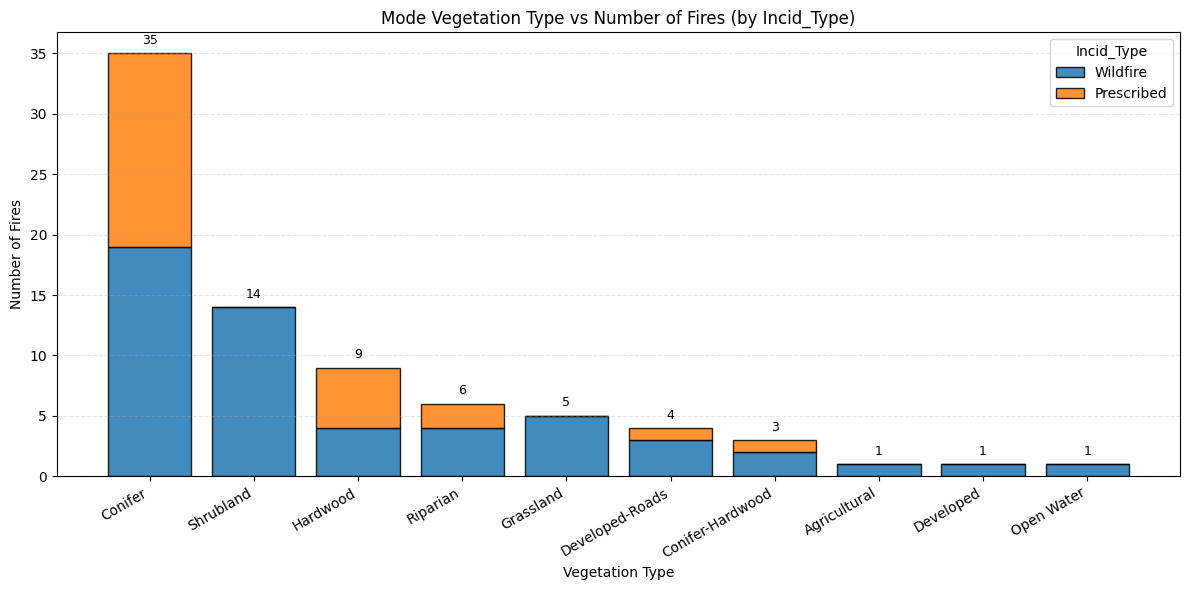

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import rasterio
from rasterio.warp import transform
import matplotlib.pyplot as plt

def plot_ignition_veg_from_cubes(
    firelist_path="/Users/pc/Desktop/2025/FireCube/FireCube-1/inputData/fireslist2012-2024_withtype.csv",
    cubes_root="/Users/pc/Desktop/2025/FireCube/FireCube-1/output/cubes",
    lf_legend_path="/Users/pc/Desktop/2025/FireCube/FireCube-1/inputData/LF2024_EVT.csv",
    fire_id_col="Event_ID",
    lon_col="lon0",
    lat_col="lat0",
    evt_relpaths=None,         # list of possible EVT rasters inside each cube
    evt_code_col="VALUE",      # column in LF2024_EVT that matches EVT codes
    evt_phys_col="EVT_PHYS",   # vegetation type column
    incid_type_col="Incid_Type",
    type_order=("Wildfire", "Prescribed"),
    type_colors=None
):
    if evt_relpaths is None:
        evt_relpaths = ["landfire/200evt.tif", "landfire/105evt.tif"]

    if type_colors is None:
        type_colors = {
            "Wildfire": "#1f77b4",
            "Prescribed": "#ff7f0e",
        }

    cubes_root = Path(cubes_root)

    fires = pd.read_csv(firelist_path)

    for col in [fire_id_col, lon_col, lat_col, incid_type_col]:
        if col not in fires.columns:
            raise ValueError(f"Column '{col}' not found in firelist")

    # Normalize Incid_Type so we only have Wildfire / Prescribed
    fires[incid_type_col] = (
        fires[incid_type_col]
        .astype(str)
        .str.strip()
        .replace({"Prescribed Fire": "Prescribed", "Wildfire": "Wildfire"})
    )
    fires = fires[fires[incid_type_col].isin(list(type_order))].copy()

    fires[fire_id_col] = fires[fire_id_col].astype(str)
    id_lengths = fires[fire_id_col].str.len()
    suffix_len = int(id_lengths.mode().iloc[0])

    # Map Event_ID -> (lon, lat, Incid_Type)
    id_to_info = {
        str(row[fire_id_col]): (float(row[lon_col]), float(row[lat_col]), str(row[incid_type_col]))
        for _, row in fires.iterrows()
    }

    lf = pd.read_csv(lf_legend_path)
    if evt_code_col not in lf.columns or evt_phys_col not in lf.columns:
        raise ValueError(
            f"Expected columns '{evt_code_col}' and '{evt_phys_col}' in {lf_legend_path}. "
            f"Available columns: {lf.columns.tolist()}"
        )

    evtcode_to_phys = dict(zip(lf[evt_code_col].astype(int), lf[evt_phys_col].astype(str)))

    rows = []

    missing_evt = 0
    zero_size_evt = 0
    cube_without_match = 0
    sample_errors = 0
    nodata_count = 0
    unknown_evt_code = 0

    nodata_cubes = []
    unknown_evt_cubes = []

    total_cube_folders = 0

    for d in cubes_root.iterdir():
        if not d.is_dir():
            continue
        total_cube_folders += 1

        name = d.name
        if len(name) < suffix_len:
            continue

        suffix = name[-suffix_len:]  # Event_ID used in CSV

        if suffix not in id_to_info:
            cube_without_match += 1
            continue

        lon, lat, incid_type = id_to_info[suffix]

        evt_path = None
        for rel in evt_relpaths:
            candidate = d / rel
            if not candidate.is_file():
                continue
            if candidate.stat().st_size == 0:
                zero_size_evt += 1
                continue
            evt_path = candidate
            break

        if evt_path is None:
            missing_evt += 1
            continue

        try:
            with rasterio.open(evt_path) as src:
                src_crs = src.crs

                # Reproject lon/lat to raster CRS if needed
                if src_crs is not None and src_crs.to_string() != "EPSG:4326":
                    xs, ys = transform("EPSG:4326", src_crs, [lon], [lat])
                    x, y = xs[0], ys[0]
                else:
                    x, y = lon, lat

                val = list(src.sample([(x, y)]))[0][0]

                # Check for nodata / invalid
                if (src.nodata is not None and val == src.nodata) or np.isnan(val):
                    nodata_count += 1
                    nodata_cubes.append(name)
                    continue

                evt_code = int(val)

                if evt_code in evtcode_to_phys:
                    veg_type = evtcode_to_phys[evt_code]
                    rows.append({
                        fire_id_col: suffix,
                        incid_type_col: incid_type,
                        "veg_type": veg_type
                    })
                else:
                    unknown_evt_code += 1
                    unknown_evt_cubes.append((name, evt_code))
                    continue

        except Exception as e:
            print(f"Warning for cube {name}: {e}")
            sample_errors += 1
            continue

    veg_df = pd.DataFrame(rows)

    print(f"Total cube folders: {total_cube_folders}")
    print(f"Valid ignition vegetation samples: {len(veg_df)}")
    print(f"Cube folders with no matching Event_ID: {cube_without_match}")
    print(f"Cube folders with missing EVT raster: {missing_evt}")
    print(f"Cube folders with zero-byte EVT raster: {zero_size_evt}")
    print(f"Sample/read errors: {sample_errors}")
    print(f"Nodata / invalid EVT values: {nodata_count}")
    print(f"Unknown EVT codes (not in legend): {unknown_evt_code}")

    if nodata_cubes:
        print("\nCubes with NoData EVT at ignition point (first 20):")
        for c in nodata_cubes[:20]:
            print("  ", c)
        if len(nodata_cubes) > 20:
            print(f"  ... and {len(nodata_cubes) - 20} more")

    if unknown_evt_cubes:
        print("\nCubes with EVT codes not found in LF2024_EVT legend (first 20):")
        for c, code in unknown_evt_cubes[:20]:
            print(f"  {c}: code={code}")
        if len(unknown_evt_cubes) > 20:
            print(f"  ... and {len(unknown_evt_cubes) - 20} more")

    if veg_df.empty:
        print("No valid ignition vegetation types collected.")
        return veg_df, pd.DataFrame()

    veg_counts_by_type = (
        veg_df.groupby(["veg_type", incid_type_col])
              .size()
              .unstack(incid_type_col)
              .fillna(0)
    )

    # Ensure both types exist as columns + consistent order
    for t in type_order:
        if t not in veg_counts_by_type.columns:
            veg_counts_by_type[t] = 0
    veg_counts_by_type = veg_counts_by_type[list(type_order)]

    # Sort by total count descending (so plot matches your earlier style)
    veg_counts_by_type = veg_counts_by_type.loc[
        veg_counts_by_type.sum(axis=1).sort_values(ascending=False).index
    ]

    # Plot stacked bar chart (2 colors)
    plt.figure(figsize=(12, 6))
    x = np.arange(len(veg_counts_by_type.index))
    bottom = np.zeros(len(x))

    for t in type_order:
        vals = veg_counts_by_type[t].to_numpy()
        plt.bar(
            veg_counts_by_type.index,
            vals,
            bottom=bottom,
            edgecolor="black",
            alpha=0.85,
            label=t,
            color=type_colors.get(t, None),
        )
        bottom += vals

    totals = veg_counts_by_type.sum(axis=1).to_numpy()
    ymax = totals.max() if len(totals) else 0
    for i, total in enumerate(totals):
        if total > 0:
            plt.text(i, total + ymax * 0.015, str(int(total)), ha="center", va="bottom", fontsize=9)

    plt.title("Mode Vegetation Type vs Number of Fires (by Incid_Type)")
    plt.xlabel("Vegetation Type")
    plt.ylabel("Number of Fires")
    plt.xticks(rotation=30, ha='right')
    plt.grid(axis="y", alpha=0.3, linestyle="--")
    plt.legend(title=incid_type_col)
    plt.tight_layout()
    plt.show()

    return veg_df, veg_counts_by_type


veg_df, veg_counts_by_type = plot_ignition_veg_from_cubes()


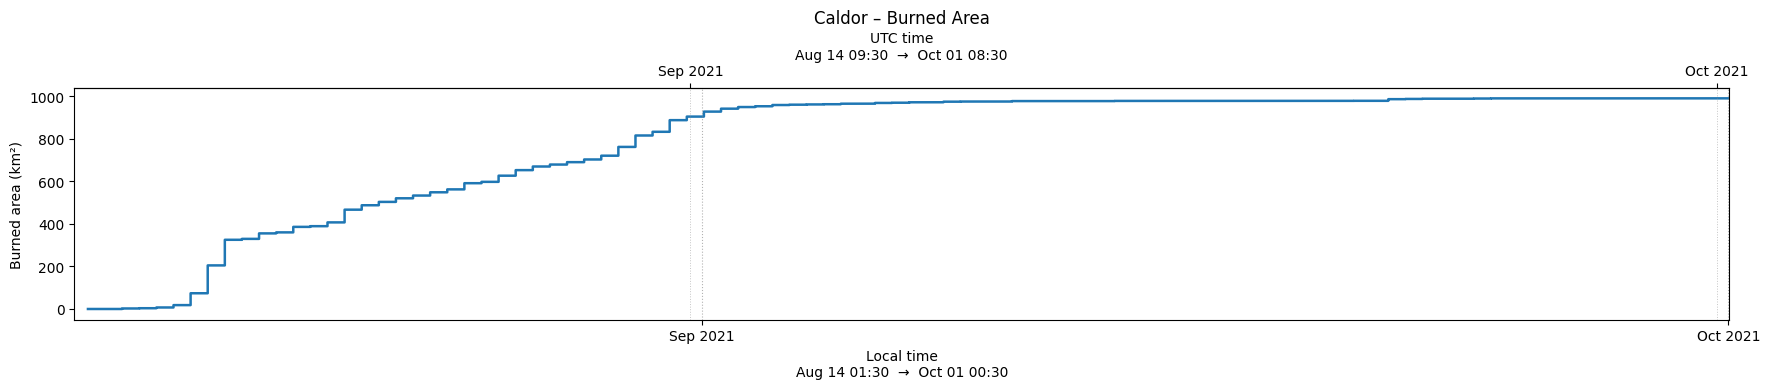

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def _span_days(lo, hi) -> float:
    dt = pd.to_datetime(hi) - pd.to_datetime(lo)
    return dt.total_seconds() / 86400.0

def _best_loc_and_fmt(lo, hi):
    """Choose tick locator/formatter based on span in days."""
    d = _span_days(lo, hi)
    if d <= 10:
        loc = mdates.DayLocator(interval=1)
        fmt = mdates.DateFormatter("%b %d")
    elif d <= 35:
        loc = mdates.WeekdayLocator(byweekday=mdates.MO, interval=1)
        fmt = mdates.DateFormatter("%b %d")
    elif d <= 120:
        loc = mdates.MonthLocator(interval=1)
        fmt = mdates.DateFormatter("%b %Y")
    else:
        loc = mdates.MonthLocator(interval=2)
        fmt = mdates.DateFormatter("%b %Y")
    return loc, fmt

def _grid_freq(lo, hi) -> str:
    d = _span_days(lo, hi)
    if d <= 10:   return "D"
    if d <= 35:   return "W-MON"
    if d <= 120:  return "MS"
    return "2MS"

def _iter_ticks(start, end, freq):
    s = pd.to_datetime(start)
    e = pd.to_datetime(end)
    rng = pd.date_range(start=s.floor("D"), end=e.ceil("D"), freq=freq)
    return rng[(rng >= s) & (rng <= e)]

def _maybe_wider_fig(lo, hi, base=(12, 4)):
    """Widen figure for longer fires, like in your example."""
    d = _span_days(lo, hi)
    width = max(base[0], min(22, 12 + 0.12 * d))
    return (width, base[1])

def _make_axis_converters(local_series: pd.Series, utc_series: pd.Series):
    """
    Build mapping functions:
      local2utc(x_local_num) -> x_utc_num
      utc2local(x_utc_num)   -> x_local_num
    where x_*_num are matplotlib date numbers.
    """
    xL = mdates.date2num(pd.to_datetime(local_series))
    xU = mdates.date2num(pd.to_datetime(utc_series))

    # Sort by Local and drop duplicate Local values
    order = np.argsort(xL)
    xL, xU = xL[order], xU[order]
    maskL = np.concatenate([[True], np.diff(xL) > 0])
    xL, xU = xL[maskL], xU[maskL]

    def local2utc(x):
        return np.interp(x, xL, xU, left=xU[0], right=xU[-1])

    # Sort by UTC and drop duplicate UTC values
    orderU = np.argsort(xU)
    xU2, xL2 = xU[orderU], xL[orderU]
    maskU = np.concatenate([[True], np.diff(xU2) > 0])
    xU2, xL2 = xU2[maskU], xL2[maskU]

    def utc2local(x):
        return np.interp(x, xU2, xL2, left=xL2[0], right=xL2[-1])

    return local2utc, utc2local

csv_path = "/Users/pc/Desktop/2025/FireCube/FireCube-1/output/sum_vis/CA3858612053820210815_CALDOR/data_table_CA3858612053820210815_CALDOR.csv"  # change if needed

# Load & sort
df = (
    pd.read_csv(csv_path, sep="\t", parse_dates=["UTC", "Local"])
      .sort_values("Local")
      .reset_index(drop=True)
)

# Full window
LOCAL_START = df["Local"].iloc[0]
LOCAL_END   = df["Local"].iloc[-1]
UTC_START   = df["UTC"].iloc[0]
UTC_END     = df["UTC"].iloc[-1]

# Build converters for synced UTC axis
local2utc, utc2local = _make_axis_converters(df["Local"], df["UTC"])

# Use fperim_area_km2 as burned area (km²)
col = "fperim_area_km2"
d = df[["UTC", "Local", col]].dropna(subset=[col])
if d.empty:
    raise ValueError(f"No data for column {col}")

loL, hiL = d["Local"].iloc[[0, -1]]
loU, hiU = d["UTC"].iloc[[0, -1]]

fig, ax = plt.subplots(figsize=_maybe_wider_fig(LOCAL_START, LOCAL_END))
ax.set_axisbelow(True)

# Burned area as a step plot
ax.step(d["Local"], d[col], where="post", linewidth=1.8)
ax.set_ylabel("Burned area (km²)")

# X-axis (bottom): Local time
ax.set_xlim(LOCAL_START, LOCAL_END)
locL, fmtL = _best_loc_and_fmt(LOCAL_START, LOCAL_END)
ax.xaxis.set_major_locator(locL)
ax.xaxis.set_major_formatter(fmtL)
ax.set_xlabel(f"Local time\n{loL:%b %d %H:%M}  →  {hiL:%b %d %H:%M}")

# Top axis: UTC time, synced via local2utc/utc2local
secax = ax.secondary_xaxis("top", functions=(local2utc, utc2local))
locU, fmtU = _best_loc_and_fmt(UTC_START, UTC_END)
secax.xaxis.set_major_locator(locU)
secax.xaxis.set_major_formatter(fmtU)
secax.set_xlabel(f"UTC time\n{loU:%b %d %H:%M}  →  {hiU:%b %d %H:%M}")

# Vertical guides in local time
gfreq_local = _grid_freq(LOCAL_START, LOCAL_END)
for dt in _iter_ticks(LOCAL_START, LOCAL_END, gfreq_local):
    ax.axvline(dt, linestyle=":", linewidth=0.8, alpha=0.6, color="grey")

# Vertical guides in UTC (mapped to local positions)
gfreq_utc = _grid_freq(UTC_START, UTC_END)
for ut in _iter_ticks(UTC_START, UTC_END, gfreq_utc):
    num_local = utc2local(mdates.date2num(pd.to_datetime(ut)))
    ax.axvline(mdates.num2date(num_local),
               linestyle=":", linewidth=0.7, alpha=0.45, color="grey")

ax.set_title("Caldor – Burned Area")

fig.tight_layout()
plt.show()


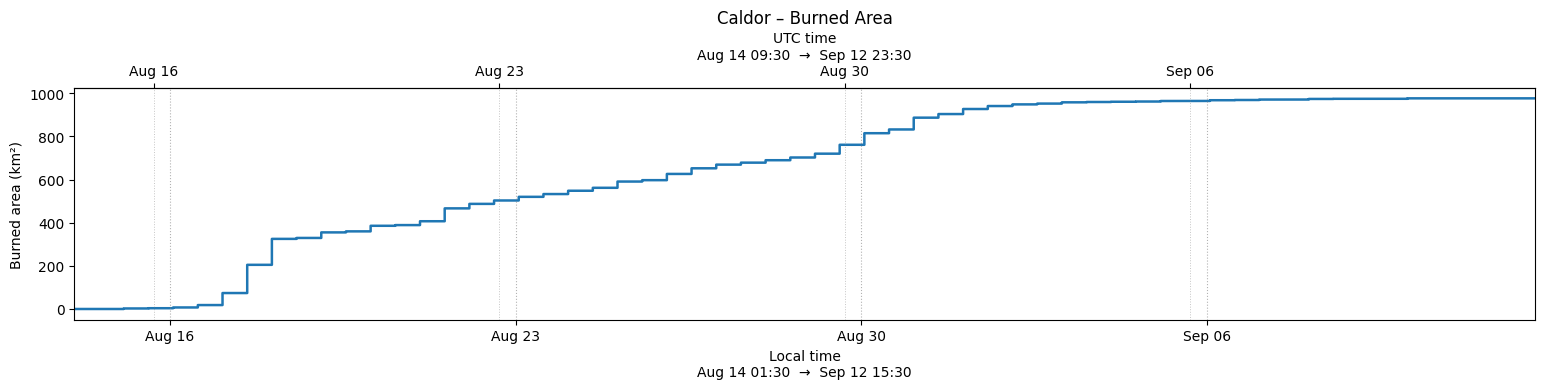

In [ ]:
col = "fperim_area_km2"
if col not in df.columns:
    raise ValueError(f"Column {col} not found in CSV. Available: {df.columns.tolist()}")

cutoff_utc = pd.Timestamp("2021-09-13 00:00:00")

# time + data masks
mask_time = df["UTC"] <= cutoff_utc
area_raw  = df[col].astype(float)

mask = mask_time & area_raw.notna()

t_local = df.loc[mask, "Local"]
t_utc   = df.loc[mask, "UTC"]
area    = area_raw[mask]

if area.empty:
    raise ValueError(f"No {col} values before UTC 2021-09-13.")

# shortened window
LOCAL_START_SUB = t_local.iloc[0]
LOCAL_END_SUB   = t_local.iloc[-1]
UTC_START_SUB   = t_utc.iloc[0]
UTC_END_SUB     = t_utc.iloc[-1]

fig, ax = plt.subplots(figsize=_maybe_wider_fig(LOCAL_START_SUB, LOCAL_END_SUB))
ax.set_axisbelow(True)

# Burned area as a step plot
ax.step(t_local, area, where="post", linewidth=1.8)
ax.set_ylabel("Burned area (km²)")

# Bottom axis: Local time
ax.set_xlim(LOCAL_START_SUB, LOCAL_END_SUB)
locL, fmtL = _best_loc_and_fmt(LOCAL_START_SUB, LOCAL_END_SUB)
ax.xaxis.set_major_locator(locL)
ax.xaxis.set_major_formatter(fmtL)

loL, hiL = t_local.iloc[[0, -1]]
loU, hiU = t_utc.iloc[[0, -1]]
ax.set_xlabel(f"Local time\n{loL:%b %d %H:%M}  →  {hiL:%b %d %H:%M}")

# Top axis: UTC time, synced via local2utc/utc2local
secax = ax.secondary_xaxis("top", functions=(local2utc, utc2local))
locU, fmtU = _best_loc_and_fmt(UTC_START_SUB, UTC_END_SUB)
secax.xaxis.set_major_locator(locU)
secax.xaxis.set_major_formatter(fmtU)
secax.set_xlabel(f"UTC time\n{loU:%b %d %H:%M}  →  {hiU:%b %d %H:%M}")

# Vertical guides in local time
gfreq_local = _grid_freq(LOCAL_START_SUB, LOCAL_END_SUB)
for dt in _iter_ticks(LOCAL_START_SUB, LOCAL_END_SUB, gfreq_local):
    ax.axvline(dt, linestyle=":", linewidth=0.8, alpha=0.6, color="grey")

# Vertical guides in UTC (mapped to local positions)
gfreq_utc = _grid_freq(UTC_START_SUB, UTC_END_SUB)
for ut in _iter_ticks(UTC_START_SUB, UTC_END_SUB, gfreq_utc):
    num_local = utc2local(mdates.date2num(pd.to_datetime(ut)))
    ax.axvline(
        mdates.num2date(num_local),
        linestyle=":", linewidth=0.7, alpha=0.45, color="grey"
    )

ax.set_title("Caldor – Burned Area")

fig.tight_layout()
plt.show()


/var/folders/53/419gvyh13dzgnkd1zfn_g5jw0000gn/T/ipykernel_5590/1647584137.py:29: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  tmp["bin_12h"] = tmp["Local"].dt.floor("12H")


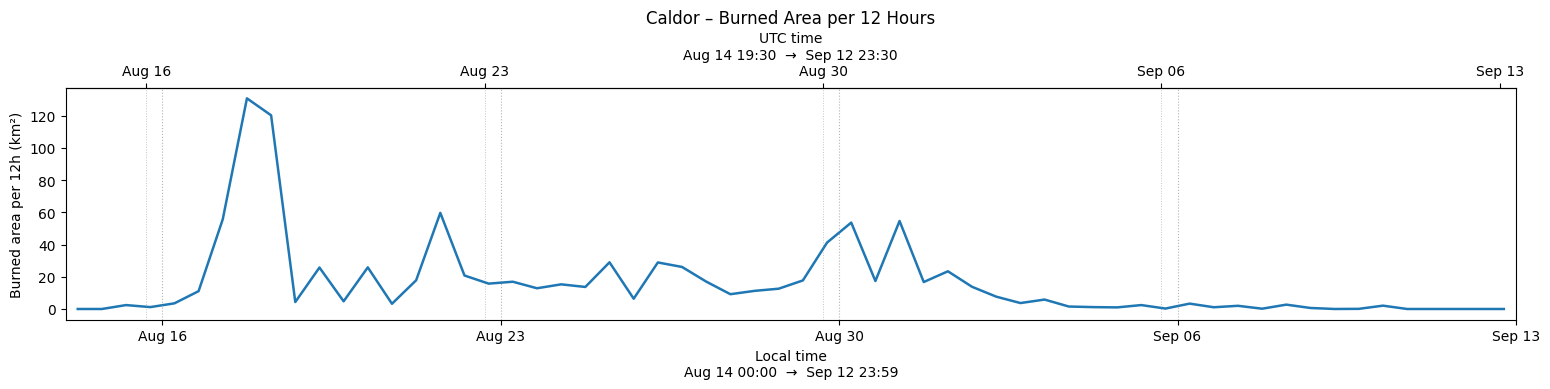

In [ ]:
col = "fperim_area_km2"
if col not in df.columns:
    raise ValueError(f"Column {col} not found in CSV. Available: {df.columns.tolist()}")

cutoff_utc = pd.Timestamp("2021-09-13 00:00:00")

# keep data up to cutoff
mask_time = df["UTC"] <= cutoff_utc
area_raw  = df[col].astype(float)
mask = mask_time & area_raw.notna()

t_local = df.loc[mask, "Local"]
t_utc   = df.loc[mask, "UTC"]
area    = area_raw[mask]

if area.empty:
    raise ValueError(f"No {col} values before UTC 2021-09-13.")

# Ensure sorted by time
tmp = (
    pd.DataFrame({"Local": t_local, "UTC": t_utc, "cum_km2": area})
      .sort_values("UTC")
      .reset_index(drop=True)
)

tmp["bin_12h"] = tmp["Local"].dt.floor("12H")

# 12-hour burned area = (12h max cumulative) - (previous 12h max cumulative)
bin_cum = tmp.groupby("bin_12h", as_index=False).agg(
    cum_km2=("cum_km2", "max"),
    UTC_last=("UTC", "max"),          # for labeling / top axis range
)

bin_cum["burned_km2_12h"] = bin_cum["cum_km2"].diff()
bin_cum.loc[bin_cum["burned_km2_12h"].isna(), "burned_km2_12h"] = bin_cum["cum_km2"].iloc[0]

bin_cum["burned_km2_12h"] = bin_cum["burned_km2_12h"].clip(lower=0)

# Plot window
LOCAL_START_SUB = bin_cum["bin_12h"].iloc[0]
LOCAL_END_SUB   = bin_cum["bin_12h"].iloc[-1] + pd.Timedelta(hours=12)
UTC_START_SUB   = bin_cum["UTC_last"].iloc[0]
UTC_END_SUB     = bin_cum["UTC_last"].iloc[-1]

fig, ax = plt.subplots(figsize=_maybe_wider_fig(LOCAL_START_SUB, LOCAL_END_SUB))
ax.set_axisbelow(True)

# Points centered on each 12h bin
x = bin_cum["bin_12h"] + pd.Timedelta(hours=6)
y = bin_cum["burned_km2_12h"]

ax.plot(x, y, linewidth=1.8)

ax.set_ylabel("Burned area per 12h (km²)")
ax.set_xlim(LOCAL_START_SUB, LOCAL_END_SUB)

# Bottom axis: Local time
locL, fmtL = _best_loc_and_fmt(LOCAL_START_SUB, LOCAL_END_SUB)
ax.xaxis.set_major_locator(locL)
ax.xaxis.set_major_formatter(fmtL)

loL, hiL = LOCAL_START_SUB, (LOCAL_END_SUB - pd.Timedelta(seconds=1))
ax.set_xlabel(f"Local time\n{loL:%b %d %H:%M}  →  {hiL:%b %d %H:%M}")

# Top axis: UTC time
secax = ax.secondary_xaxis("top", functions=(local2utc, utc2local))
locU, fmtU = _best_loc_and_fmt(UTC_START_SUB, UTC_END_SUB)
secax.xaxis.set_major_locator(locU)
secax.xaxis.set_major_formatter(fmtU)

loU, hiU = UTC_START_SUB, UTC_END_SUB
secax.set_xlabel(f"UTC time\n{loU:%b %d %H:%M}  →  {hiU:%b %d %H:%M}")

# Vertical guides (local)
gfreq_local = _grid_freq(LOCAL_START_SUB, LOCAL_END_SUB)
for dt in _iter_ticks(LOCAL_START_SUB, LOCAL_END_SUB, gfreq_local):
    ax.axvline(dt, linestyle=":", linewidth=0.8, alpha=0.6, color="grey")

# Vertical guides (UTC mapped to local)
gfreq_utc = _grid_freq(UTC_START_SUB, UTC_END_SUB)
for ut in _iter_ticks(UTC_START_SUB, UTC_END_SUB, gfreq_utc):
    num_local = utc2local(mdates.date2num(pd.to_datetime(ut)))
    ax.axvline(
        mdates.num2date(num_local),
        linestyle=":", linewidth=0.7, alpha=0.45, color="grey"
    )

ax.set_title("Caldor – Burned Area per 12 Hours")
fig.tight_layout()
plt.show()


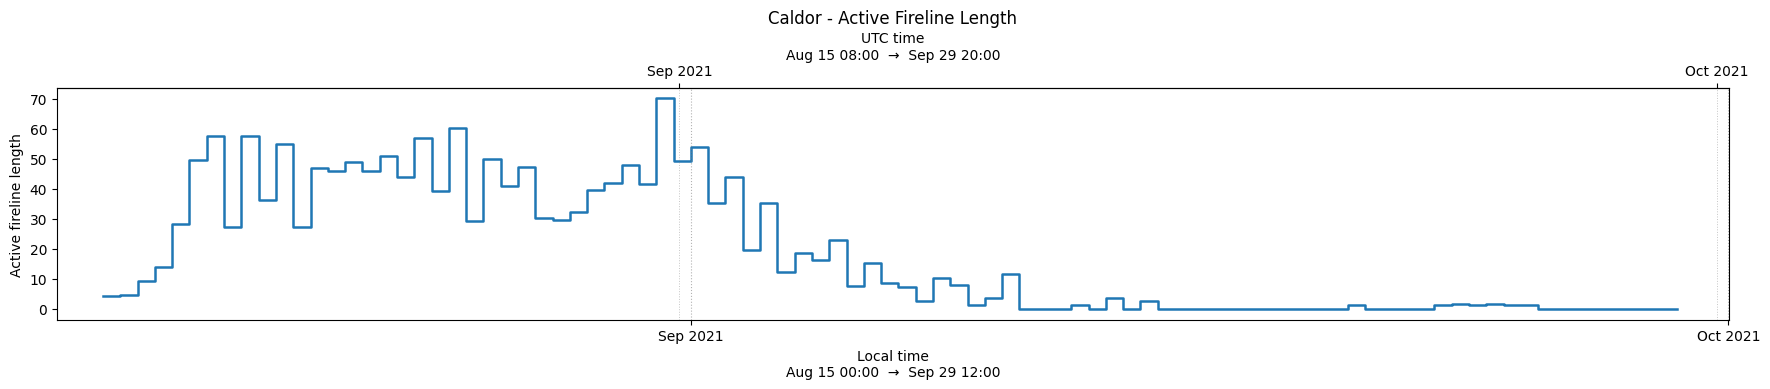

In [ ]:
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

csv_path = "/Users/pc/Desktop/2025/FireCube/FireCube-1/output/sum_vis/CA3858612053820210815_CALDOR/data_table_CA3858612053820210815_CALDOR.csv"
gpkg_path = "/Users/pc/Desktop/2025/FireCube/FireCube-1/inputData/FEDS2.5/2021/CA3858612053820210815.gpkg"

df = (
    pd.read_csv(csv_path, sep="\t", parse_dates=["UTC", "Local"])
      .sort_values("Local")
      .reset_index(drop=True)
)

# Full window
LOCAL_START = df["Local"].iloc[0]
LOCAL_END   = df["Local"].iloc[-1]
UTC_START   = df["UTC"].iloc[0]
UTC_END     = df["UTC"].iloc[-1]

# Build converters for synced UTC axis
local2utc, utc2local = _make_axis_converters(df["Local"], df["UTC"])

perim = gpd.read_file(gpkg_path, layer="perimeter")
perim["t"] = pd.to_datetime(perim["t"])

if "flinelen" not in perim.columns:
    raise ValueError(f"'flinelen' column not found in perimeter layer. Available: {perim.columns.tolist()}")

fl = perim[["t", "flinelen"]].dropna(subset=["flinelen"]).copy()
fl["Local"] = fl["t"]  # make it explicit

merged = pd.merge(
    df[["UTC", "Local"]],
    fl[["Local", "flinelen"]],
    on="Local",
    how="left"
)

d = merged.dropna(subset=["flinelen"]).copy()
if d.empty:
    raise ValueError("No overlapping timestamps between CSV and GPKG for flinelen.")

loL, hiL = d["Local"].iloc[[0, -1]]
loU, hiU = d["UTC"].iloc[[0, -1]]

fig, ax = plt.subplots(figsize=_maybe_wider_fig(LOCAL_START, LOCAL_END))
ax.set_axisbelow(True)

y = d["flinelen"]
ax.step(d["Local"], y, where="post", linewidth=1.8)
ax.set_ylabel("Active fireline length") 

# Bottom axis: Local time
ax.set_xlim(LOCAL_START, LOCAL_END)
locL, fmtL = _best_loc_and_fmt(LOCAL_START, LOCAL_END)
ax.xaxis.set_major_locator(locL)
ax.xaxis.set_major_formatter(fmtL)
ax.set_xlabel(f"Local time\n{loL:%b %d %H:%M}  →  {hiL:%b %d %H:%M}")

# Top axis: UTC time, synced via local2utc/utc2local
secax = ax.secondary_xaxis("top", functions=(local2utc, utc2local))
locU, fmtU = _best_loc_and_fmt(UTC_START, UTC_END)
secax.xaxis.set_major_locator(locU)
secax.xaxis.set_major_formatter(fmtU)
secax.set_xlabel(f"UTC time\n{loU:%b %d %H:%M}  →  {hiU:%b %d %H:%M}")

# Vertical guides in local time
gfreq_local = _grid_freq(LOCAL_START, LOCAL_END)
for dt in _iter_ticks(LOCAL_START, LOCAL_END, gfreq_local):
    ax.axvline(dt, linestyle=":", linewidth=0.8, alpha=0.6, color="grey")

# Vertical guides in UTC (mapped to local positions)
gfreq_utc = _grid_freq(UTC_START, UTC_END)
for ut in _iter_ticks(UTC_START, UTC_END, gfreq_utc):
    num_local = utc2local(mdates.date2num(pd.to_datetime(ut)))
    ax.axvline(mdates.num2date(num_local),
               linestyle=":", linewidth=0.7, alpha=0.45, color="grey")

ax.set_title("Caldor - Active Fireline Length")

fig.tight_layout()
plt.show()


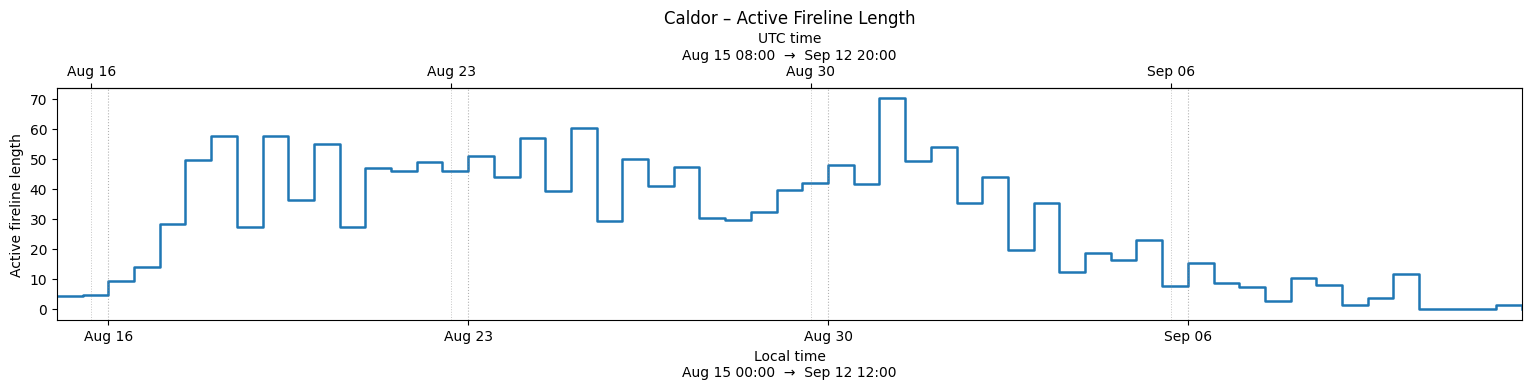

In [ ]:
if "flinelen" not in d.columns:
    raise ValueError(f"'flinelen' column not found in merged table. Available: {d.columns.tolist()}")

# cutoff in UTC
cutoff_utc = pd.Timestamp("2021-09-13 00:00:00")

# time + data masks
mask_time = d["UTC"] <= cutoff_utc
fl_raw    = d["flinelen"].astype(float)

mask = mask_time & fl_raw.notna()

t_local = d.loc[mask, "Local"]
t_utc   = d.loc[mask, "UTC"]
fl      = fl_raw[mask]

if fl.empty:
    raise ValueError("No flinelen values before UTC 2021-09-13.")

# shortened window
LOCAL_START_SUB = t_local.iloc[0]
LOCAL_END_SUB   = t_local.iloc[-1]
UTC_START_SUB   = t_utc.iloc[0]
UTC_END_SUB     = t_utc.iloc[-1]

local2utc, utc2local = _make_axis_converters(df["Local"], df["UTC"])

fig, ax = plt.subplots(figsize=_maybe_wider_fig(LOCAL_START_SUB, LOCAL_END_SUB))
ax.set_axisbelow(True)

ax.step(t_local, fl, where="post", linewidth=1.8)
ax.set_ylabel("Active fireline length")  # add units if you know them

# Bottom axis: Local time
ax.set_xlim(LOCAL_START_SUB, LOCAL_END_SUB)
locL, fmtL = _best_loc_and_fmt(LOCAL_START_SUB, LOCAL_END_SUB)
ax.xaxis.set_major_locator(locL)
ax.xaxis.set_major_formatter(fmtL)

loL, hiL = t_local.iloc[[0, -1]]
loU, hiU = t_utc.iloc[[0, -1]]
ax.set_xlabel(f"Local time\n{loL:%b %d %H:%M}  →  {hiL:%b %d %H:%M}")

# Top axis: UTC time, synced via local2utc/utc2local
secax = ax.secondary_xaxis("top", functions=(local2utc, utc2local))
locU, fmtU = _best_loc_and_fmt(UTC_START_SUB, UTC_END_SUB)
secax.xaxis.set_major_locator(locU)
secax.xaxis.set_major_formatter(fmtU)
secax.set_xlabel(f"UTC time\n{loU:%b %d %H:%M}  →  {hiU:%b %d %H:%M}")

# Vertical guides in local time
gfreq_local = _grid_freq(LOCAL_START_SUB, LOCAL_END_SUB)
for dt in _iter_ticks(LOCAL_START_SUB, LOCAL_END_SUB, gfreq_local):
    ax.axvline(dt, linestyle=":", linewidth=0.8, alpha=0.6, color="grey")

# Vertical guides in UTC (mapped to local positions)
gfreq_utc = _grid_freq(UTC_START_SUB, UTC_END_SUB)
for ut in _iter_ticks(UTC_START_SUB, UTC_END_SUB, gfreq_utc):
    num_local = utc2local(mdates.date2num(pd.to_datetime(ut)))
    ax.axvline(
        mdates.num2date(num_local),
        linestyle=":", linewidth=0.7, alpha=0.45, color="grey"
    )

ax.set_title("Caldor – Active Fireline Length")

fig.tight_layout()
plt.show()


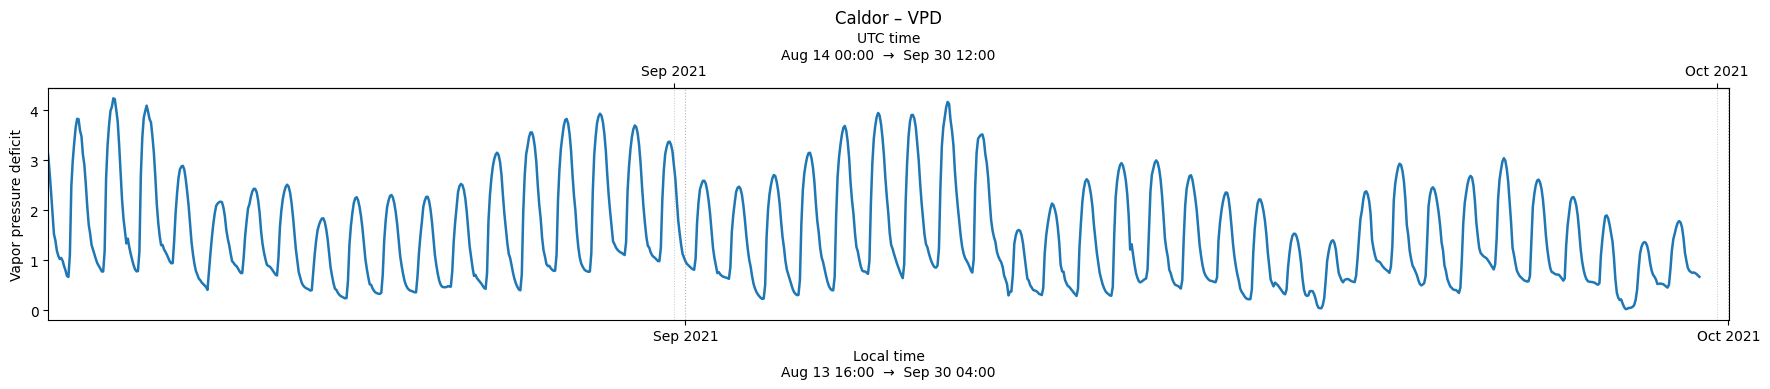

In [ ]:
if "vpd" not in df.columns:
    raise ValueError(f"'vpd' column not found in CSV. Available: {df.columns.tolist()}")

vpd = df["vpd"].astype(float)

mask = vpd.notna()
t_local = df["Local"][mask]
t_utc   = df["UTC"][mask]
vpd     = vpd[mask]

if vpd.empty:
    raise ValueError("No valid VPD values to plot.")

local2utc, utc2local = _make_axis_converters(df["Local"], df["UTC"])

fig, ax = plt.subplots(figsize=_maybe_wider_fig(LOCAL_START, LOCAL_END))
ax.set_axisbelow(True)

ax.plot(t_local, vpd, linewidth=1.8)
ax.set_ylabel("Vapor pressure deficit")

# Bottom axis: Local time
ax.set_xlim(LOCAL_START, LOCAL_END)
locL, fmtL = _best_loc_and_fmt(LOCAL_START, LOCAL_END)
ax.xaxis.set_major_locator(locL)
ax.xaxis.set_major_formatter(fmtL)

loL, hiL = t_local.iloc[[0, -1]]
loU, hiU = t_utc.iloc[[0, -1]]

ax.set_xlabel(f"Local time\n{loL:%b %d %H:%M}  →  {hiL:%b %d %H:%M}")

# Top axis: UTC time, synced via local2utc/utc2local
secax = ax.secondary_xaxis("top", functions=(local2utc, utc2local))
locU, fmtU = _best_loc_and_fmt(UTC_START, UTC_END)
secax.xaxis.set_major_locator(locU)
secax.xaxis.set_major_formatter(fmtU)
secax.set_xlabel(f"UTC time\n{loU:%b %d %H:%M}  →  {hiU:%b %d %H:%M}")

# Vertical guides in local time
gfreq_local = _grid_freq(LOCAL_START, LOCAL_END)
for dt in _iter_ticks(LOCAL_START, LOCAL_END, gfreq_local):
    ax.axvline(dt, linestyle=":", linewidth=0.8, alpha=0.6, color="grey")

# Vertical guides in UTC (mapped to local positions)
gfreq_utc = _grid_freq(UTC_START, UTC_END)
for ut in _iter_ticks(UTC_START, UTC_END, gfreq_utc):
    num_local = utc2local(mdates.date2num(pd.to_datetime(ut)))
    ax.axvline(
        mdates.num2date(num_local),
        linestyle=":", linewidth=0.7, alpha=0.45, color="grey"
    )

ax.set_title("Caldor – VPD")

fig.tight_layout()
plt.show()


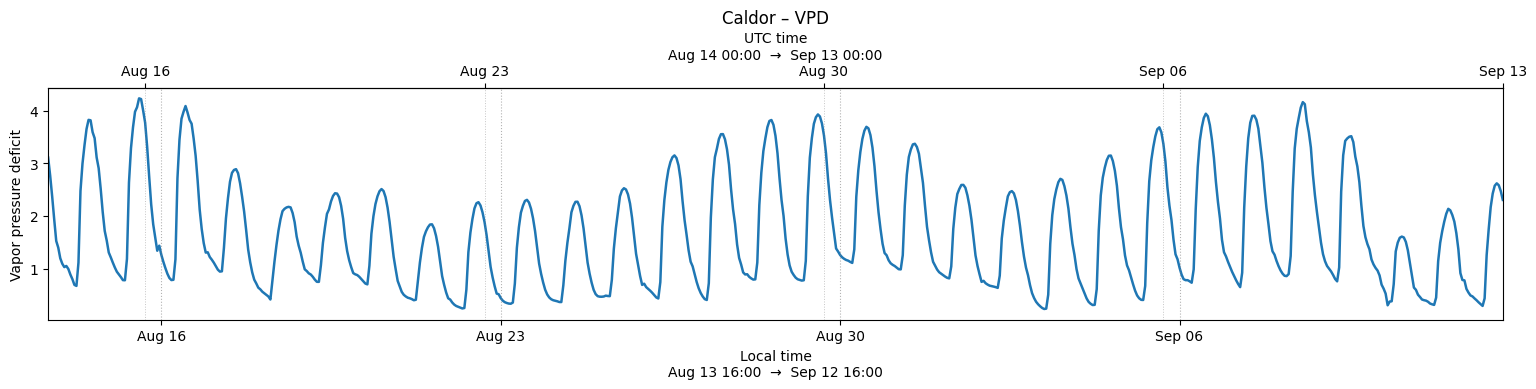

In [ ]:
if "vpd" not in df.columns:
    raise ValueError(f"'vpd' column not found in CSV. Available: {df.columns.tolist()}")

# cutoff in UTC
cutoff_utc = pd.Timestamp("2021-09-13 00:00:00")

# time + data masks
mask_time = df["UTC"] <= cutoff_utc
vpd_raw   = df["vpd"].astype(float)

mask = mask_time & vpd_raw.notna()

t_local = df.loc[mask, "Local"]
t_utc   = df.loc[mask, "UTC"]
vpd     = vpd_raw[mask]

if vpd.empty:
    raise ValueError("No valid VPD values before UTC 2021-09-13.")

# shortened window
LOCAL_START_SUB = t_local.iloc[0]
LOCAL_END_SUB   = t_local.iloc[-1]
UTC_START_SUB   = t_utc.iloc[0]
UTC_END_SUB     = t_utc.iloc[-1]

local2utc, utc2local = _make_axis_converters(df["Local"], df["UTC"])

fig, ax = plt.subplots(figsize=_maybe_wider_fig(LOCAL_START_SUB, LOCAL_END_SUB))
ax.set_axisbelow(True)

ax.plot(t_local, vpd, linewidth=1.8)
ax.set_ylabel("Vapor pressure deficit")

# Bottom axis: Local time
ax.set_xlim(LOCAL_START_SUB, LOCAL_END_SUB)
locL, fmtL = _best_loc_and_fmt(LOCAL_START_SUB, LOCAL_END_SUB)
ax.xaxis.set_major_locator(locL)
ax.xaxis.set_major_formatter(fmtL)

loL, hiL = t_local.iloc[[0, -1]]
loU, hiU = t_utc.iloc[[0, -1]]
ax.set_xlabel(f"Local time\n{loL:%b %d %H:%M}  →  {hiL:%b %d %H:%M}")

# Top axis: UTC time, synced via local2utc/utc2local
secax = ax.secondary_xaxis("top", functions=(local2utc, utc2local))
locU, fmtU = _best_loc_and_fmt(UTC_START_SUB, UTC_END_SUB)
secax.xaxis.set_major_locator(locU)
secax.xaxis.set_major_formatter(fmtU)
secax.set_xlabel(f"UTC time\n{loU:%b %d %H:%M}  →  {hiU:%b %d %H:%M}")

# Vertical guides in local time
gfreq_local = _grid_freq(LOCAL_START_SUB, LOCAL_END_SUB)
for dt in _iter_ticks(LOCAL_START_SUB, LOCAL_END_SUB, gfreq_local):
    ax.axvline(dt, linestyle=":", linewidth=0.8, alpha=0.6, color="grey")

# Vertical guides in UTC (mapped to local positions)
gfreq_utc = _grid_freq(UTC_START_SUB, UTC_END_SUB)
for ut in _iter_ticks(UTC_START_SUB, UTC_END_SUB, gfreq_utc):
    num_local = utc2local(mdates.date2num(pd.to_datetime(ut)))
    ax.axvline(
        mdates.num2date(num_local),
        linestyle=":", linewidth=0.7, alpha=0.45, color="grey"
    )

ax.set_title("Caldor – VPD")

fig.tight_layout()
plt.show()


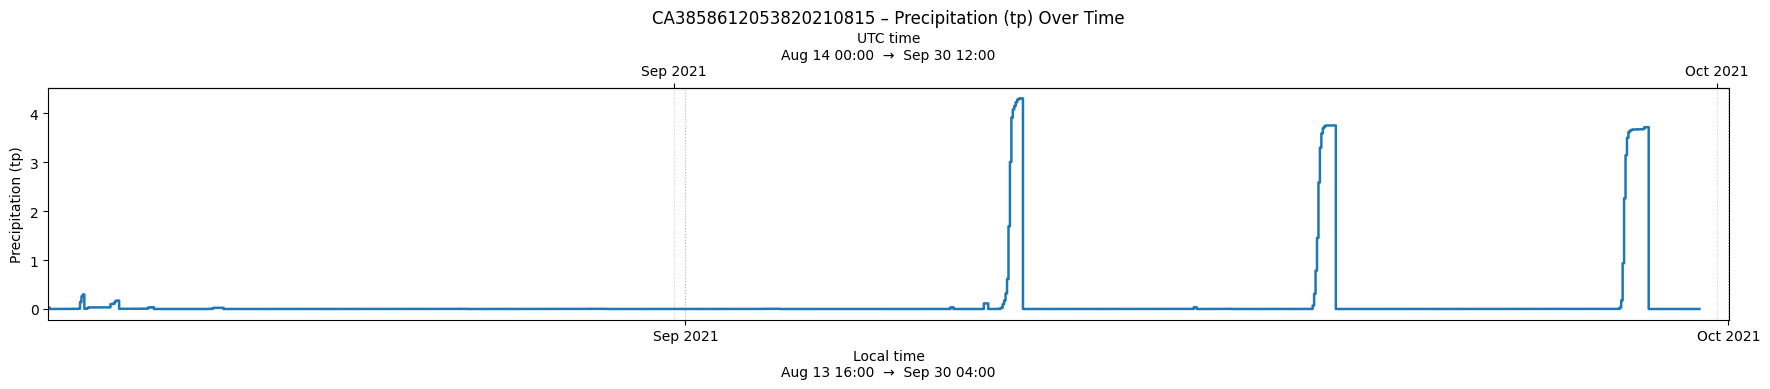

In [ ]:
if "tp" not in df.columns:
    raise ValueError("'tp' column not found in CSV.")

precip = df["tp"].astype(float)

# Remove missing values
mask = precip.notna()
t_local = df["Local"][mask]
t_utc   = df["UTC"][mask]
precip  = precip[mask]

if precip.empty:
    raise ValueError("No valid tp (precipitation) values to plot.")

local2utc, utc2local = _make_axis_converters(df["Local"], df["UTC"])

fig, ax = plt.subplots(figsize=_maybe_wider_fig(LOCAL_START, LOCAL_END))
ax.set_axisbelow(True)

# For precipitation, step-style is usually most correct (accumulated/bucketed)
ax.step(t_local, precip, where="post", linewidth=1.8)
ax.set_ylabel("Precipitation (tp)")

ax.set_xlim(LOCAL_START, LOCAL_END)
locL, fmtL = _best_loc_and_fmt(LOCAL_START, LOCAL_END)
ax.xaxis.set_major_locator(locL)
ax.xaxis.set_major_formatter(fmtL)

loL, hiL = t_local.iloc[[0, -1]]
loU, hiU = t_utc.iloc[[0, -1]]
ax.set_xlabel(f"Local time\n{loL:%b %d %H:%M}  →  {hiL:%b %d %H:%M}")

secax = ax.secondary_xaxis("top", functions=(local2utc, utc2local))
locU, fmtU = _best_loc_and_fmt(UTC_START, UTC_END)
secax.xaxis.set_major_locator(locU)
secax.xaxis.set_major_formatter(fmtU)
secax.set_xlabel(f"UTC time\n{loU:%b %d %H:%M}  →  {hiU:%b %d %H:%M}")

gfreq_local = _grid_freq(LOCAL_START, LOCAL_END)
for dt in _iter_ticks(LOCAL_START, LOCAL_END, gfreq_local):
    ax.axvline(dt, linestyle=":", linewidth=0.8, alpha=0.6, color="grey")

gfreq_utc = _grid_freq(UTC_START, UTC_END)
for ut in _iter_ticks(UTC_START, UTC_END, gfreq_utc):
    num_local = utc2local(mdates.date2num(pd.to_datetime(ut)))
    ax.axvline(
        mdates.num2date(num_local),
        linestyle=":", linewidth=0.7, alpha=0.45, color="grey",
    )

ax.set_title("CA3858612053820210815 – Precipitation (tp) Over Time")

fig.tight_layout()
plt.show()


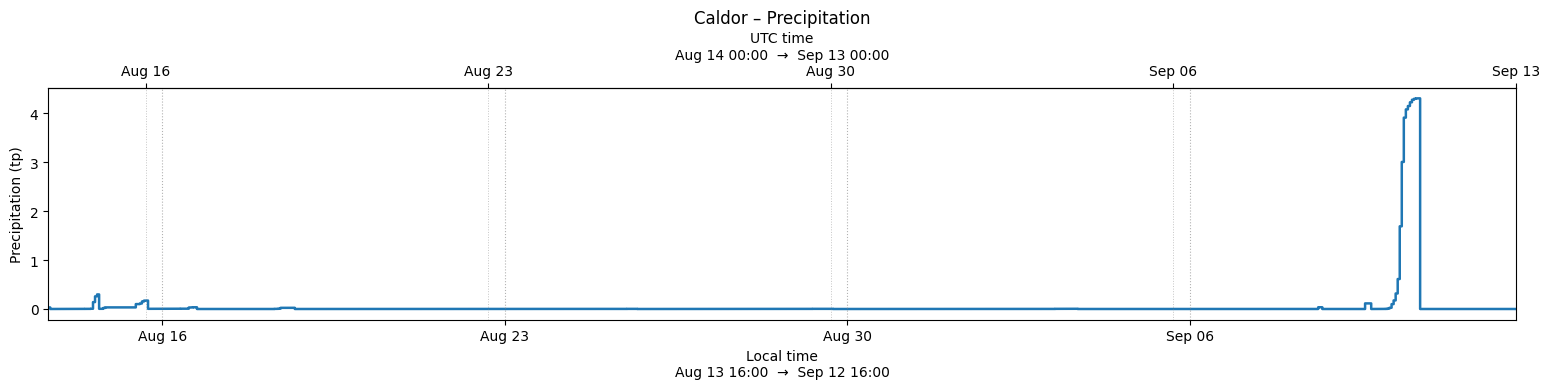

In [ ]:
if "tp" not in df.columns:
    raise ValueError("'tp' column not found in CSV.")

cutoff_utc = pd.Timestamp("2021-09-13 00:00:00")

# time + NaN mask
mask_time = df["UTC"] <= cutoff_utc
mask_data = df["tp"].notna()
mask = mask_time & mask_data

t_local = df.loc[mask, "Local"]
t_utc   = df.loc[mask, "UTC"]
precip  = df.loc[mask, "tp"].astype(float)

if precip.empty:
    raise ValueError("No valid tp (precipitation) values before UTC 2021-09-15.")

# Shortened window
LOCAL_START_SUB = t_local.iloc[0]
LOCAL_END_SUB   = t_local.iloc[-1]
UTC_START_SUB   = t_utc.iloc[0]
UTC_END_SUB     = t_utc.iloc[-1]

local2utc, utc2local = _make_axis_converters(df["Local"], df["UTC"])

fig, ax = plt.subplots(figsize=_maybe_wider_fig(LOCAL_START_SUB, LOCAL_END_SUB))
ax.set_axisbelow(True)

ax.step(t_local, precip, where="post", linewidth=1.8)
ax.set_ylabel("Precipitation (tp)")

ax.set_xlim(LOCAL_START_SUB, LOCAL_END_SUB)
locL, fmtL = _best_loc_and_fmt(LOCAL_START_SUB, LOCAL_END_SUB)
ax.xaxis.set_major_locator(locL)
ax.xaxis.set_major_formatter(fmtL)

loL, hiL = t_local.iloc[[0, -1]]
loU, hiU = t_utc.iloc[[0, -1]]
ax.set_xlabel(f"Local time\n{loL:%b %d %H:%M}  →  {hiL:%b %d %H:%M}")

secax = ax.secondary_xaxis("top", functions=(local2utc, utc2local))
locU, fmtU = _best_loc_and_fmt(UTC_START_SUB, UTC_END_SUB)
secax.xaxis.set_major_locator(locU)
secax.xaxis.set_major_formatter(fmtU)
secax.set_xlabel(f"UTC time\n{loU:%b %d %H:%M}  →  {hiU:%b %d %H:%M}")

gfreq_local = _grid_freq(LOCAL_START_SUB, LOCAL_END_SUB)
for dt in _iter_ticks(LOCAL_START_SUB, LOCAL_END_SUB, gfreq_local):
    ax.axvline(dt, linestyle=":", linewidth=0.8, alpha=0.6, color="grey")

gfreq_utc = _grid_freq(UTC_START_SUB, UTC_END_SUB)
for ut in _iter_ticks(UTC_START_SUB, UTC_END_SUB, gfreq_utc):
    num_local = utc2local(mdates.date2num(pd.to_datetime(ut)))
    ax.axvline(
        mdates.num2date(num_local),
        linestyle=":", linewidth=0.7, alpha=0.45, color="grey",
    )

ax.set_title("Caldor – Precipitation")

fig.tight_layout()
plt.show()


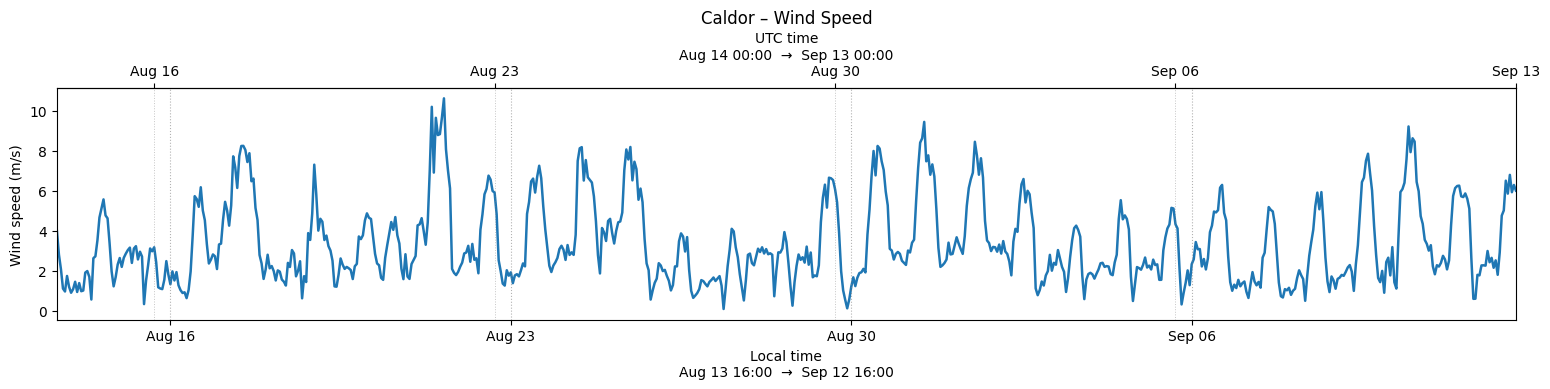

In [ ]:
col = "ws_mean"
if col not in df.columns:
    raise ValueError(f"'{col}' not found in CSV. Available: {df.columns.tolist()}")

# cutoff in UTC
cutoff_utc = pd.Timestamp("2021-09-13 00:00:00")

# time + data masks
mask_time = df["UTC"] <= cutoff_utc
ws_raw    = df[col].astype(float)

mask = mask_time & ws_raw.notna()

t_local = df.loc[mask, "Local"]
t_utc   = df.loc[mask, "UTC"]
ws      = ws_raw[mask]

if ws.empty:
    raise ValueError("No valid ws_mean (wind speed) values before UTC 2021-09-13.")

# shortened window
LOCAL_START_SUB = t_local.iloc[0]
LOCAL_END_SUB   = t_local.iloc[-1]
UTC_START_SUB   = t_utc.iloc[0]
UTC_END_SUB     = t_utc.iloc[-1]

fig, ax = plt.subplots(figsize=_maybe_wider_fig(LOCAL_START_SUB, LOCAL_END_SUB))
ax.set_axisbelow(True)

ax.plot(t_local, ws, linewidth=1.8)
ax.set_ylabel("Wind speed (m/s)")   # adjust units if needed

# Bottom axis: Local time
ax.set_xlim(LOCAL_START_SUB, LOCAL_END_SUB)
locL, fmtL = _best_loc_and_fmt(LOCAL_START_SUB, LOCAL_END_SUB)
ax.xaxis.set_major_locator(locL)
ax.xaxis.set_major_formatter(fmtL)

loL, hiL = t_local.iloc[[0, -1]]
loU, hiU = t_utc.iloc[[0, -1]]
ax.set_xlabel(f"Local time\n{loL:%b %d %H:%M}  →  {hiL:%b %d %H:%M}")

# Top axis: UTC time, synced via local2utc/utc2local
secax = ax.secondary_xaxis("top", functions=(local2utc, utc2local))
locU, fmtU = _best_loc_and_fmt(UTC_START_SUB, UTC_END_SUB)
secax.xaxis.set_major_locator(locU)
secax.xaxis.set_major_formatter(fmtU)
secax.set_xlabel(f"UTC time\n{loU:%b %d %H:%M}  →  {hiU:%b %d %H:%M}")

# Vertical guides in local time
gfreq_local = _grid_freq(LOCAL_START_SUB, LOCAL_END_SUB)
for dt in _iter_ticks(LOCAL_START_SUB, LOCAL_END_SUB, gfreq_local):
    ax.axvline(dt, linestyle=":", linewidth=0.8, alpha=0.6, color="grey")

# Vertical guides in UTC (mapped to local positions)
gfreq_utc = _grid_freq(UTC_START_SUB, UTC_END_SUB)
for ut in _iter_ticks(UTC_START_SUB, UTC_END_SUB, gfreq_utc):
    num_local = utc2local(mdates.date2num(pd.to_datetime(ut)))
    ax.axvline(
        mdates.num2date(num_local),
        linestyle=":", linewidth=0.7, alpha=0.45, color="grey"
    )

ax.set_title("Caldor – Wind Speed")

fig.tight_layout()
plt.show()


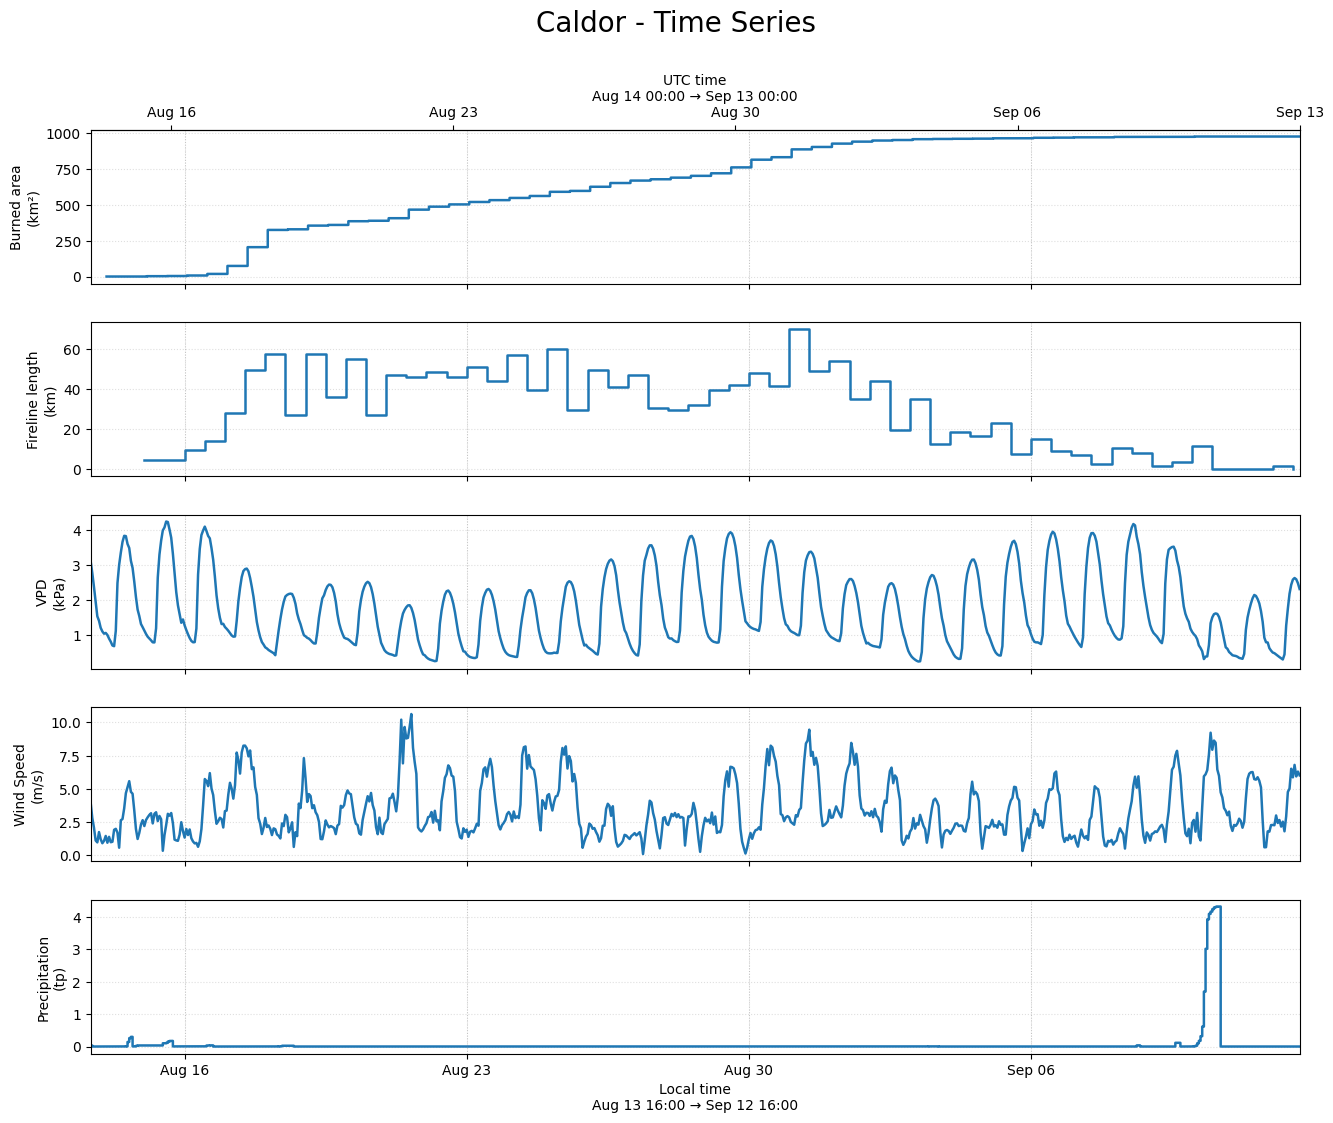

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

cutoff_utc = pd.Timestamp("2021-09-13 00:00:00")

# Build converters once from full series
local2utc, utc2local = _make_axis_converters(df["Local"], df["UTC"])

# Helper: clip a column from df by UTC cutoff
def clip_from_df(colname, cutoff):
    if colname not in df.columns:
        raise ValueError(f"{colname} not in df.columns")
    mask = (df["UTC"] <= cutoff) & df[colname].notna()
    t_local = df.loc[mask, "Local"]
    t_utc   = df.loc[mask, "UTC"]
    values  = df.loc[mask, colname].astype(float)
    if values.empty:
        raise ValueError(f"No valid {colname} values before {cutoff}.")
    return t_local, t_utc, values


# Burned area
t_local_area, t_utc_area, area = clip_from_df("fperim_area_km2", cutoff_utc)

# VPD
t_local_vpd, t_utc_vpd, vpd = clip_from_df("vpd", cutoff_utc)

# Wind speed
t_local_ws, t_utc_ws, ws = clip_from_df("ws_mean", cutoff_utc)

# Precipitation
t_local_tp, t_utc_tp, tp = clip_from_df("tp", cutoff_utc)

# Fireline length from merged table d
if "flinelen" not in d.columns:
    raise ValueError("'flinelen' not found in merged table d.")
mask_fl = (d["UTC"] <= cutoff_utc) & d["flinelen"].notna()
t_local_fl = d.loc[mask_fl, "Local"]
t_utc_fl   = d.loc[mask_fl, "UTC"]
fl         = d.loc[mask_fl, "flinelen"].astype(float)
if fl.empty:
    raise ValueError("No flinelen values before cutoff.")


LOCAL_START_SUB = min(
    t_local_area.min(), t_local_fl.min(),
    t_local_vpd.min(), t_local_ws.min(),
    t_local_tp.min()
)
LOCAL_END_SUB = max(
    t_local_area.max(), t_local_fl.max(),
    t_local_vpd.max(), t_local_ws.max(),
    t_local_tp.max()
)

UTC_START_SUB = min(
    t_utc_area.min(), t_utc_fl.min(),
    t_utc_vpd.min(), t_utc_ws.min(),
    t_utc_tp.min()
)
UTC_END_SUB = max(
    t_utc_area.max(), t_utc_fl.max(),
    t_utc_vpd.max(), t_utc_ws.max(),
    t_utc_tp.max()
)

# Pick a nice figure size based on fire duration
width, _ = _maybe_wider_fig(LOCAL_START_SUB, LOCAL_END_SUB)
fig, axes = plt.subplots(
    nrows=5, ncols=1,
    figsize=(width, 12),
    sharex=True,
    gridspec_kw={"hspace": 0.25}
)

ax_area, ax_fl, ax_vpd, ax_ws, ax_tp = axes


# 1) Burned area
ax_area.step(t_local_area, area, where="post", linewidth=1.8)
ax_area.set_ylabel("Burned area\n(km²)")
ax_area.grid(alpha=0.4, linestyle=":")

# 2) Fireline length
ax_fl.step(t_local_fl, fl, where="post", linewidth=1.8)
ax_fl.set_ylabel("Fireline length\n(km)")
ax_fl.grid(alpha=0.4, linestyle=":")

# 3) VPD
ax_vpd.plot(t_local_vpd, vpd, linewidth=1.8)
ax_vpd.set_ylabel("VPD\n(kPa)")
ax_vpd.grid(alpha=0.4, linestyle=":")

# 4) Wind speed
ax_ws.plot(t_local_ws, ws, linewidth=1.8)
ax_ws.set_ylabel("Wind Speed\n(m/s)")
ax_ws.grid(alpha=0.4, linestyle=":")

# 5) Precipitation
ax_tp.step(t_local_tp, tp, where="post", linewidth=1.8)
ax_tp.set_ylabel("Precipitation\n(tp)")
ax_tp.grid(alpha=0.4, linestyle=":")


ax_tp.set_xlim(LOCAL_START_SUB, LOCAL_END_SUB)
locL, fmtL = _best_loc_and_fmt(LOCAL_START_SUB, LOCAL_END_SUB)
ax_tp.xaxis.set_major_locator(locL)
ax_tp.xaxis.set_major_formatter(fmtL)

ax_tp.set_xlabel(
    f"Local time\n{LOCAL_START_SUB:%b %d %H:%M} → {LOCAL_END_SUB:%b %d %H:%M}"
)


secax = ax_area.secondary_xaxis("top", functions=(local2utc, utc2local))
locU, fmtU = _best_loc_and_fmt(UTC_START_SUB, UTC_END_SUB)
secax.xaxis.set_major_locator(locU)
secax.xaxis.set_major_formatter(fmtU)
secax.set_xlabel(
    f"UTC time\n{UTC_START_SUB:%b %d %H:%M} → {UTC_END_SUB:%b %d %H:%M}"
)


gfreq_local = _grid_freq(LOCAL_START_SUB, LOCAL_END_SUB)
for dt in _iter_ticks(LOCAL_START_SUB, LOCAL_END_SUB, gfreq_local):
    for ax in axes:
        ax.axvline(dt, linestyle=":", linewidth=0.7, alpha=0.35, color="grey")

plt.suptitle("Caldor - Time Series", y=0.98, fontsize=20)
plt.show()


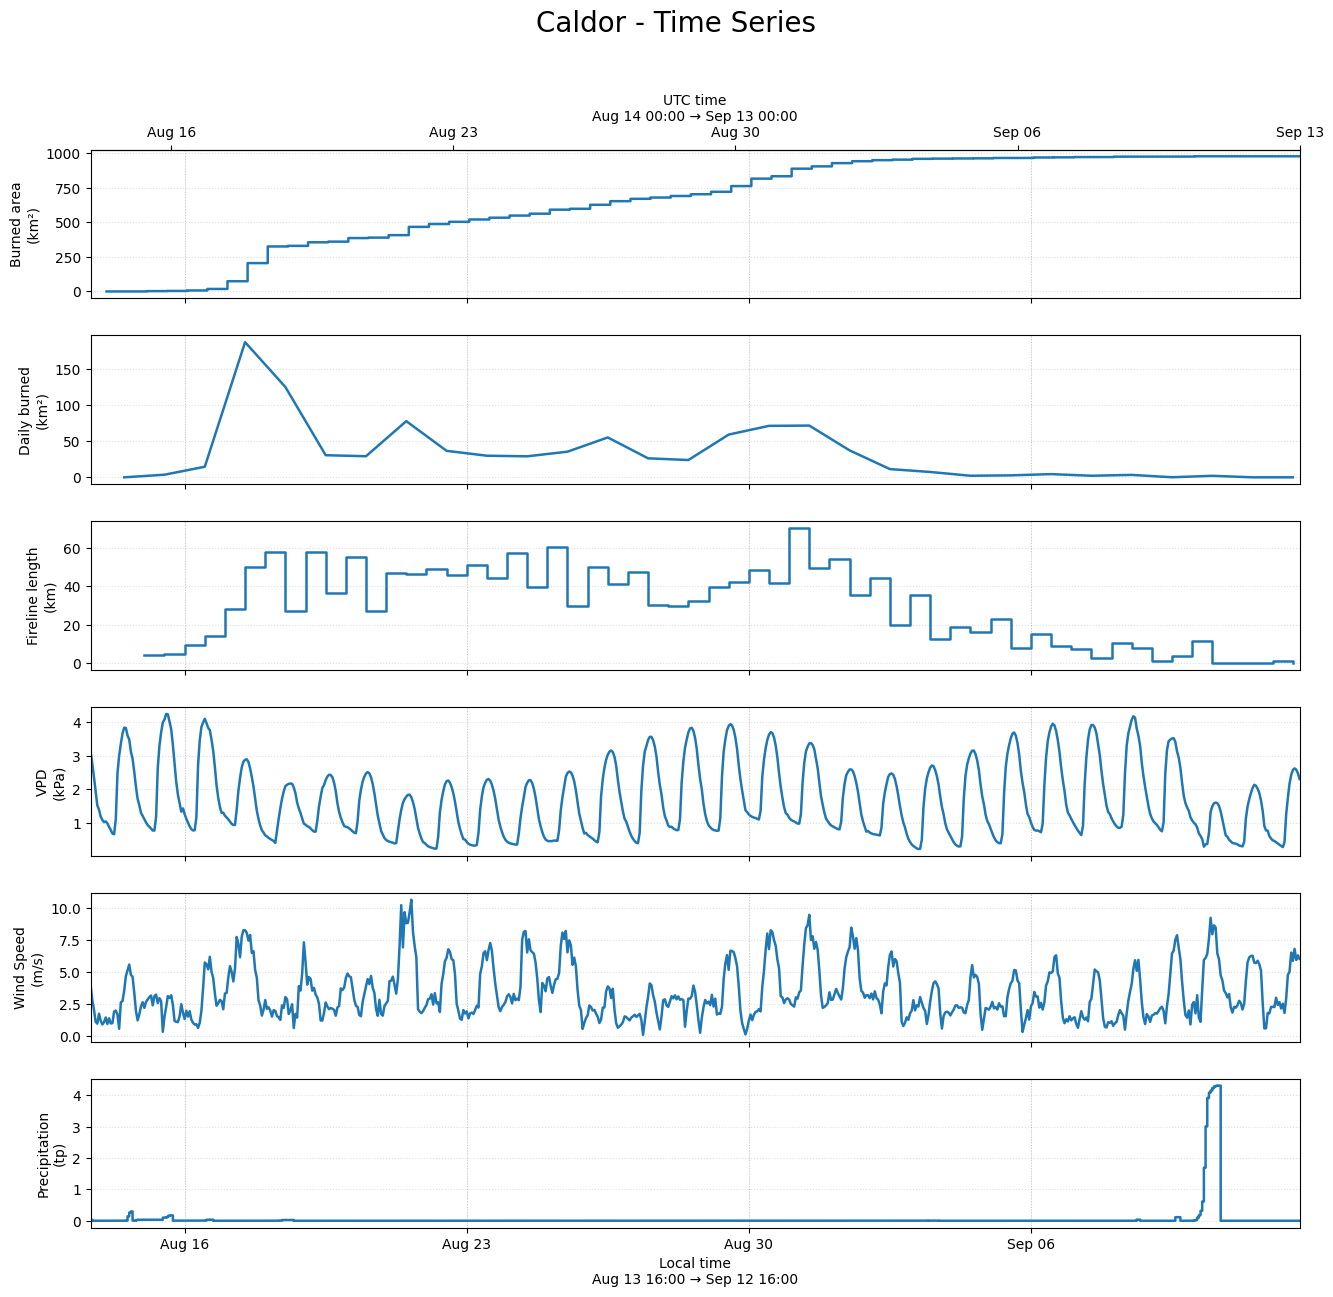

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

cutoff_utc = pd.Timestamp("2021-09-13 00:00:00")

# Build converters once from full series
local2utc, utc2local = _make_axis_converters(df["Local"], df["UTC"])

# Helper: clip a column from df by UTC cutoff
def clip_from_df(colname, cutoff):
    if colname not in df.columns:
        raise ValueError(f"{colname} not in df.columns")
    mask = (df["UTC"] <= cutoff) & df[colname].notna()
    t_local = df.loc[mask, "Local"]
    t_utc   = df.loc[mask, "UTC"]
    values  = df.loc[mask, colname].astype(float)
    if values.empty:
        raise ValueError(f"No valid {colname} values before {cutoff}.")
    return t_local, t_utc, values

# Burned area (cumulative)
t_local_area, t_utc_area, area = clip_from_df("fperim_area_km2", cutoff_utc)

area_df = (
    pd.DataFrame({"Local": t_local_area, "UTC": t_utc_area, "cum_km2": area})
    .sort_values("UTC")
    .reset_index(drop=True)
)
area_df["day_local"] = area_df["Local"].dt.floor("D")  # local-day bins
daily_area = (
    area_df.groupby("day_local", as_index=False)
    .agg(daily_km2=("cum_km2", lambda x: x.max() - x.min()))
)
daily_area["x_local"] = daily_area["day_local"] + pd.Timedelta(hours=12)  # center in day

# VPD
t_local_vpd, t_utc_vpd, vpd = clip_from_df("vpd", cutoff_utc)

# Wind speed
t_local_ws, t_utc_ws, ws = clip_from_df("ws_mean", cutoff_utc)

# Precipitation
t_local_tp, t_utc_tp, tp = clip_from_df("tp", cutoff_utc)

# Fireline length from merged table d
if "flinelen" not in d.columns:
    raise ValueError("'flinelen' not found in merged table d.")
mask_fl = (d["UTC"] <= cutoff_utc) & d["flinelen"].notna()
t_local_fl = d.loc[mask_fl, "Local"]
t_utc_fl   = d.loc[mask_fl, "UTC"]
fl         = d.loc[mask_fl, "flinelen"].astype(float)
if fl.empty:
    raise ValueError("No flinelen values before cutoff.")

LOCAL_START_SUB = min(
    t_local_area.min(), daily_area["x_local"].min(), t_local_fl.min(),
    t_local_vpd.min(), t_local_ws.min(), t_local_tp.min()
)
LOCAL_END_SUB = max(
    t_local_area.max(), daily_area["x_local"].max(), t_local_fl.max(),
    t_local_vpd.max(), t_local_ws.max(), t_local_tp.max()
)

UTC_START_SUB = min(
    t_utc_area.min(), t_utc_fl.min(),
    t_utc_vpd.min(), t_utc_ws.min(), t_utc_tp.min()
)
UTC_END_SUB = max(
    t_utc_area.max(), t_utc_fl.max(),
    t_utc_vpd.max(), t_utc_ws.max(), t_utc_tp.max()
)

width, _ = _maybe_wider_fig(LOCAL_START_SUB, LOCAL_END_SUB)
fig, axes = plt.subplots(
    nrows=6, ncols=1,                  
    figsize=(width, 14),              
    sharex=True,
    gridspec_kw={"hspace": 0.25}
)

ax_area, ax_daily, ax_fl, ax_vpd, ax_ws, ax_tp = axes

# 1) Burned area (cumulative)
ax_area.step(t_local_area, area, where="post", linewidth=1.8)
ax_area.set_ylabel("Burned area\n(km²)")
ax_area.grid(alpha=0.4, linestyle=":")

# 2) Daily burned area
ax_daily.plot(daily_area["x_local"], daily_area["daily_km2"], linewidth=1.8)
ax_daily.set_ylabel("Daily burned\n(km²)")
ax_daily.grid(alpha=0.4, linestyle=":")

# 3) Fireline length
ax_fl.step(t_local_fl, fl, where="post", linewidth=1.8)
ax_fl.set_ylabel("Fireline length\n(km)")
ax_fl.grid(alpha=0.4, linestyle=":")

# 4) VPD
ax_vpd.plot(t_local_vpd, vpd, linewidth=1.8)
ax_vpd.set_ylabel("VPD\n(kPa)")
ax_vpd.grid(alpha=0.4, linestyle=":")

# 5) Wind speed
ax_ws.plot(t_local_ws, ws, linewidth=1.8)
ax_ws.set_ylabel("Wind Speed\n(m/s)")
ax_ws.grid(alpha=0.4, linestyle=":")

# 6) Precipitation
ax_tp.step(t_local_tp, tp, where="post", linewidth=1.8)
ax_tp.set_ylabel("Precipitation\n(tp)")
ax_tp.grid(alpha=0.4, linestyle=":")

ax_tp.set_xlim(LOCAL_START_SUB, LOCAL_END_SUB)
locL, fmtL = _best_loc_and_fmt(LOCAL_START_SUB, LOCAL_END_SUB)
ax_tp.xaxis.set_major_locator(locL)
ax_tp.xaxis.set_major_formatter(fmtL)

ax_tp.set_xlabel(
    f"Local time\n{LOCAL_START_SUB:%b %d %H:%M} → {LOCAL_END_SUB:%b %d %H:%M}"
)

secax = ax_area.secondary_xaxis("top", functions=(local2utc, utc2local))
locU, fmtU = _best_loc_and_fmt(UTC_START_SUB, UTC_END_SUB)
secax.xaxis.set_major_locator(locU)
secax.xaxis.set_major_formatter(fmtU)
secax.set_xlabel(
    f"UTC time\n{UTC_START_SUB:%b %d %H:%M} → {UTC_END_SUB:%b %d %H:%M}"
)

gfreq_local = _grid_freq(LOCAL_START_SUB, LOCAL_END_SUB)
for dt in _iter_ticks(LOCAL_START_SUB, LOCAL_END_SUB, gfreq_local):
    for ax in axes:
        ax.axvline(dt, linestyle=":", linewidth=0.7, alpha=0.35, color="grey")

plt.suptitle("Caldor - Time Series", y=0.98, fontsize=20)
plt.show()


/var/folders/53/419gvyh13dzgnkd1zfn_g5jw0000gn/T/ipykernel_5590/1019341746.py:37: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  area_df["bin_12h"] = area_df["Local"].dt.floor("12H")


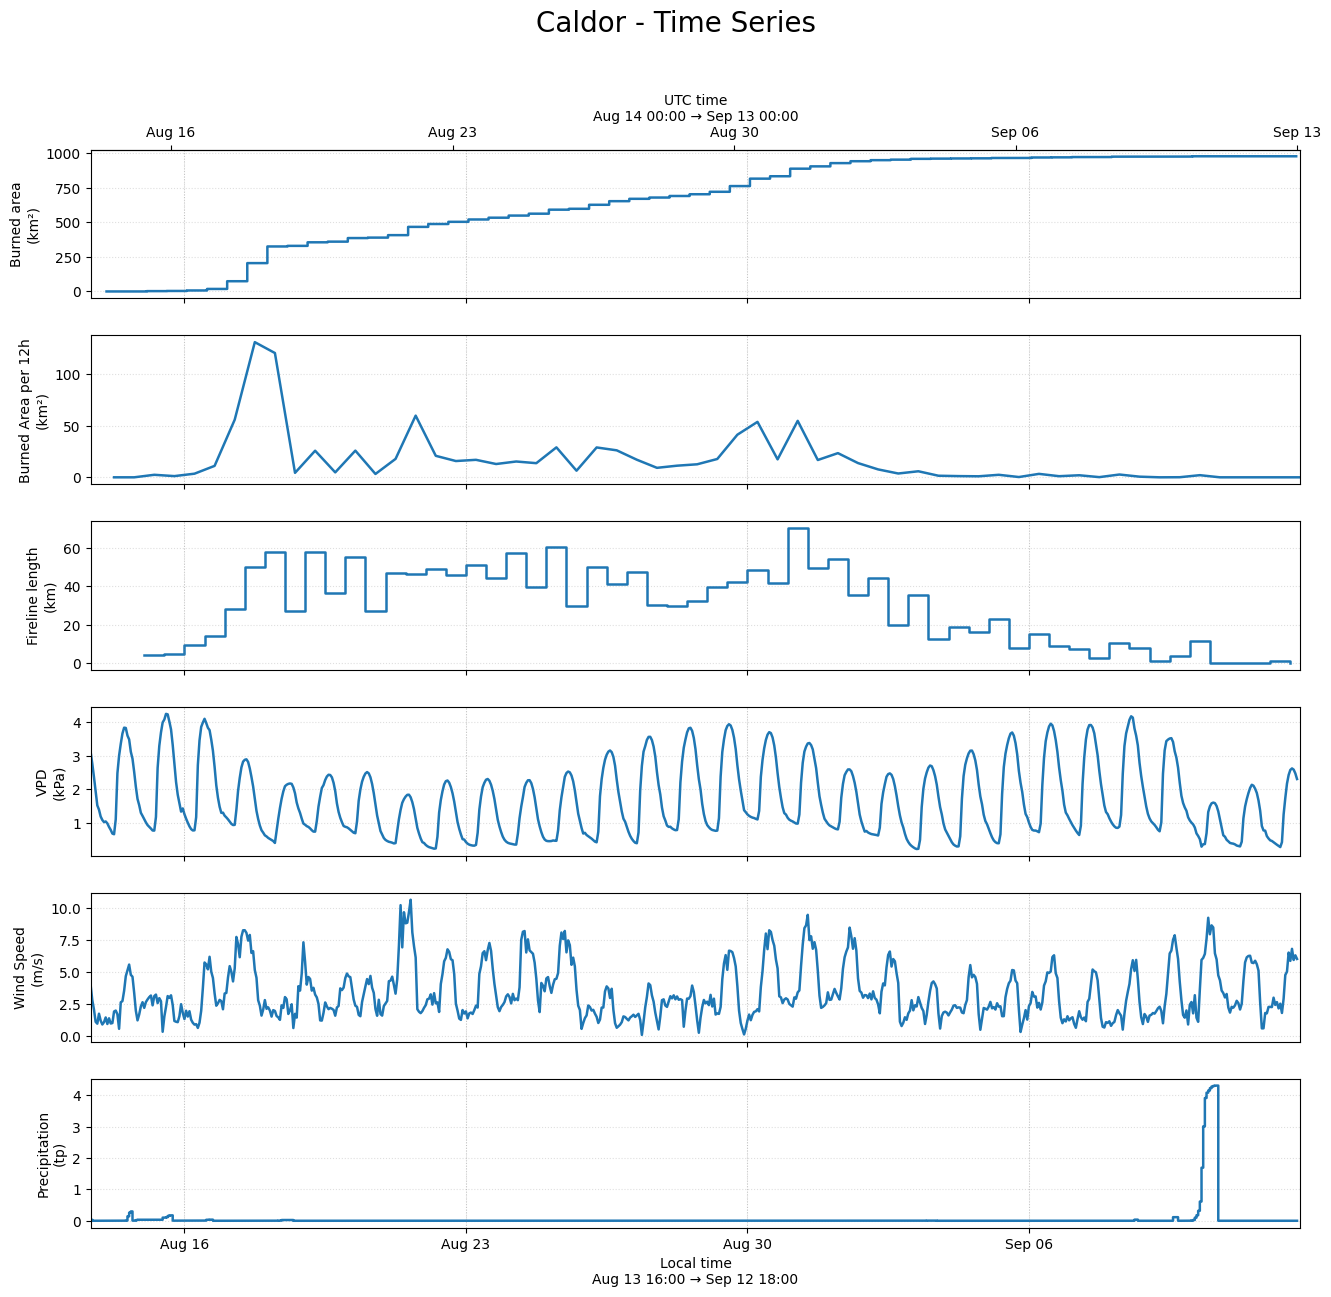

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

cutoff_utc = pd.Timestamp("2021-09-13 00:00:00")

# Build converters once from full series
local2utc, utc2local = _make_axis_converters(df["Local"], df["UTC"])

# Helper: clip a column from df by UTC cutoff
def clip_from_df(colname, cutoff):
    if colname not in df.columns:
        raise ValueError(f"{colname} not in df.columns")
    mask = (df["UTC"] <= cutoff) & df[colname].notna()
    t_local = df.loc[mask, "Local"]
    t_utc   = df.loc[mask, "UTC"]
    values  = df.loc[mask, colname].astype(float)
    if values.empty:
        raise ValueError(f"No valid {colname} values before {cutoff}.")
    return t_local, t_utc, values


# Burned area (cumulative)
t_local_area, t_utc_area, area = clip_from_df("fperim_area_km2", cutoff_utc)

area_df = (
    pd.DataFrame({"Local": t_local_area, "UTC": t_utc_area, "cum_km2": area})
    .sort_values("UTC")
    .reset_index(drop=True)
)

area_df["bin_12h"] = area_df["Local"].dt.floor("12H")

# Burned area per 12h = max(cum) - min(cum) within that 12h bin
area_12h = (
    area_df.groupby("bin_12h", as_index=False)
    .agg(burned_km2_12h=("cum_km2", lambda x: x.max() - x.min()))
)

area_12h["burned_km2_12h"] = area_12h["burned_km2_12h"].clip(lower=0)

# Center points in each 12h window for plotting
area_12h["x_local"] = area_12h["bin_12h"] + pd.Timedelta(hours=6)

# VPD
t_local_vpd, t_utc_vpd, vpd = clip_from_df("vpd", cutoff_utc)

# Wind speed
t_local_ws, t_utc_ws, ws = clip_from_df("ws_mean", cutoff_utc)

# Precipitation
t_local_tp, t_utc_tp, tp = clip_from_df("tp", cutoff_utc)

# Fireline length from merged table d
if "flinelen" not in d.columns:
    raise ValueError("'flinelen' not found in merged table d.")
mask_fl = (d["UTC"] <= cutoff_utc) & d["flinelen"].notna()
t_local_fl = d.loc[mask_fl, "Local"]
t_utc_fl   = d.loc[mask_fl, "UTC"]
fl         = d.loc[mask_fl, "flinelen"].astype(float)
if fl.empty:
    raise ValueError("No flinelen values before cutoff.")


LOCAL_START_SUB = min(
    t_local_area.min(), area_12h["x_local"].min(), t_local_fl.min(),
    t_local_vpd.min(), t_local_ws.min(), t_local_tp.min()
)
LOCAL_END_SUB = max(
    t_local_area.max(), area_12h["x_local"].max(), t_local_fl.max(),
    t_local_vpd.max(), t_local_ws.max(), t_local_tp.max()
)

UTC_START_SUB = min(
    t_utc_area.min(), t_utc_fl.min(),
    t_utc_vpd.min(), t_utc_ws.min(), t_utc_tp.min()
)
UTC_END_SUB = max(
    t_utc_area.max(), t_utc_fl.max(),
    t_utc_vpd.max(), t_utc_ws.max(), t_utc_tp.max()
)

width, _ = _maybe_wider_fig(LOCAL_START_SUB, LOCAL_END_SUB)
fig, axes = plt.subplots(
    nrows=6, ncols=1,
    figsize=(width, 14),
    sharex=True,
    gridspec_kw={"hspace": 0.25}
)

ax_area, ax_12h, ax_fl, ax_vpd, ax_ws, ax_tp = axes


# 1) Burned area (cumulative)
ax_area.step(t_local_area, area, where="post", linewidth=1.8)
ax_area.set_ylabel("Burned area\n(km²)")
ax_area.grid(alpha=0.4, linestyle=":")

# 2) Burned area per 12 hours
ax_12h.plot(area_12h["x_local"], area_12h["burned_km2_12h"], linewidth=1.8)
ax_12h.set_ylabel("Burned Area per 12h\n(km²)")
ax_12h.grid(alpha=0.4, linestyle=":")

# 3) Fireline length
ax_fl.step(t_local_fl, fl, where="post", linewidth=1.8)
ax_fl.set_ylabel("Fireline length\n(km)")
ax_fl.grid(alpha=0.4, linestyle=":")

# 4) VPD
ax_vpd.plot(t_local_vpd, vpd, linewidth=1.8)
ax_vpd.set_ylabel("VPD\n(kPa)")
ax_vpd.grid(alpha=0.4, linestyle=":")

# 5) Wind speed
ax_ws.plot(t_local_ws, ws, linewidth=1.8)
ax_ws.set_ylabel("Wind Speed\n(m/s)")
ax_ws.grid(alpha=0.4, linestyle=":")

# 6) Precipitation
ax_tp.step(t_local_tp, tp, where="post", linewidth=1.8)
ax_tp.set_ylabel("Precipitation\n(tp)")
ax_tp.grid(alpha=0.4, linestyle=":")


ax_tp.set_xlim(LOCAL_START_SUB, LOCAL_END_SUB)
locL, fmtL = _best_loc_and_fmt(LOCAL_START_SUB, LOCAL_END_SUB)
ax_tp.xaxis.set_major_locator(locL)
ax_tp.xaxis.set_major_formatter(fmtL)

ax_tp.set_xlabel(
    f"Local time\n{LOCAL_START_SUB:%b %d %H:%M} → {LOCAL_END_SUB:%b %d %H:%M}"
)


secax = ax_area.secondary_xaxis("top", functions=(local2utc, utc2local))
locU, fmtU = _best_loc_and_fmt(UTC_START_SUB, UTC_END_SUB)
secax.xaxis.set_major_locator(locU)
secax.xaxis.set_major_formatter(fmtU)
secax.set_xlabel(
    f"UTC time\n{UTC_START_SUB:%b %d %H:%M} → {UTC_END_SUB:%b %d %H:%M}"
)


gfreq_local = _grid_freq(LOCAL_START_SUB, LOCAL_END_SUB)
for dt in _iter_ticks(LOCAL_START_SUB, LOCAL_END_SUB, gfreq_local):
    for ax in axes:
        ax.axvline(dt, linestyle=":", linewidth=0.7, alpha=0.35, color="grey")

plt.suptitle("Caldor - Time Series", y=0.98, fontsize=20)
plt.show()


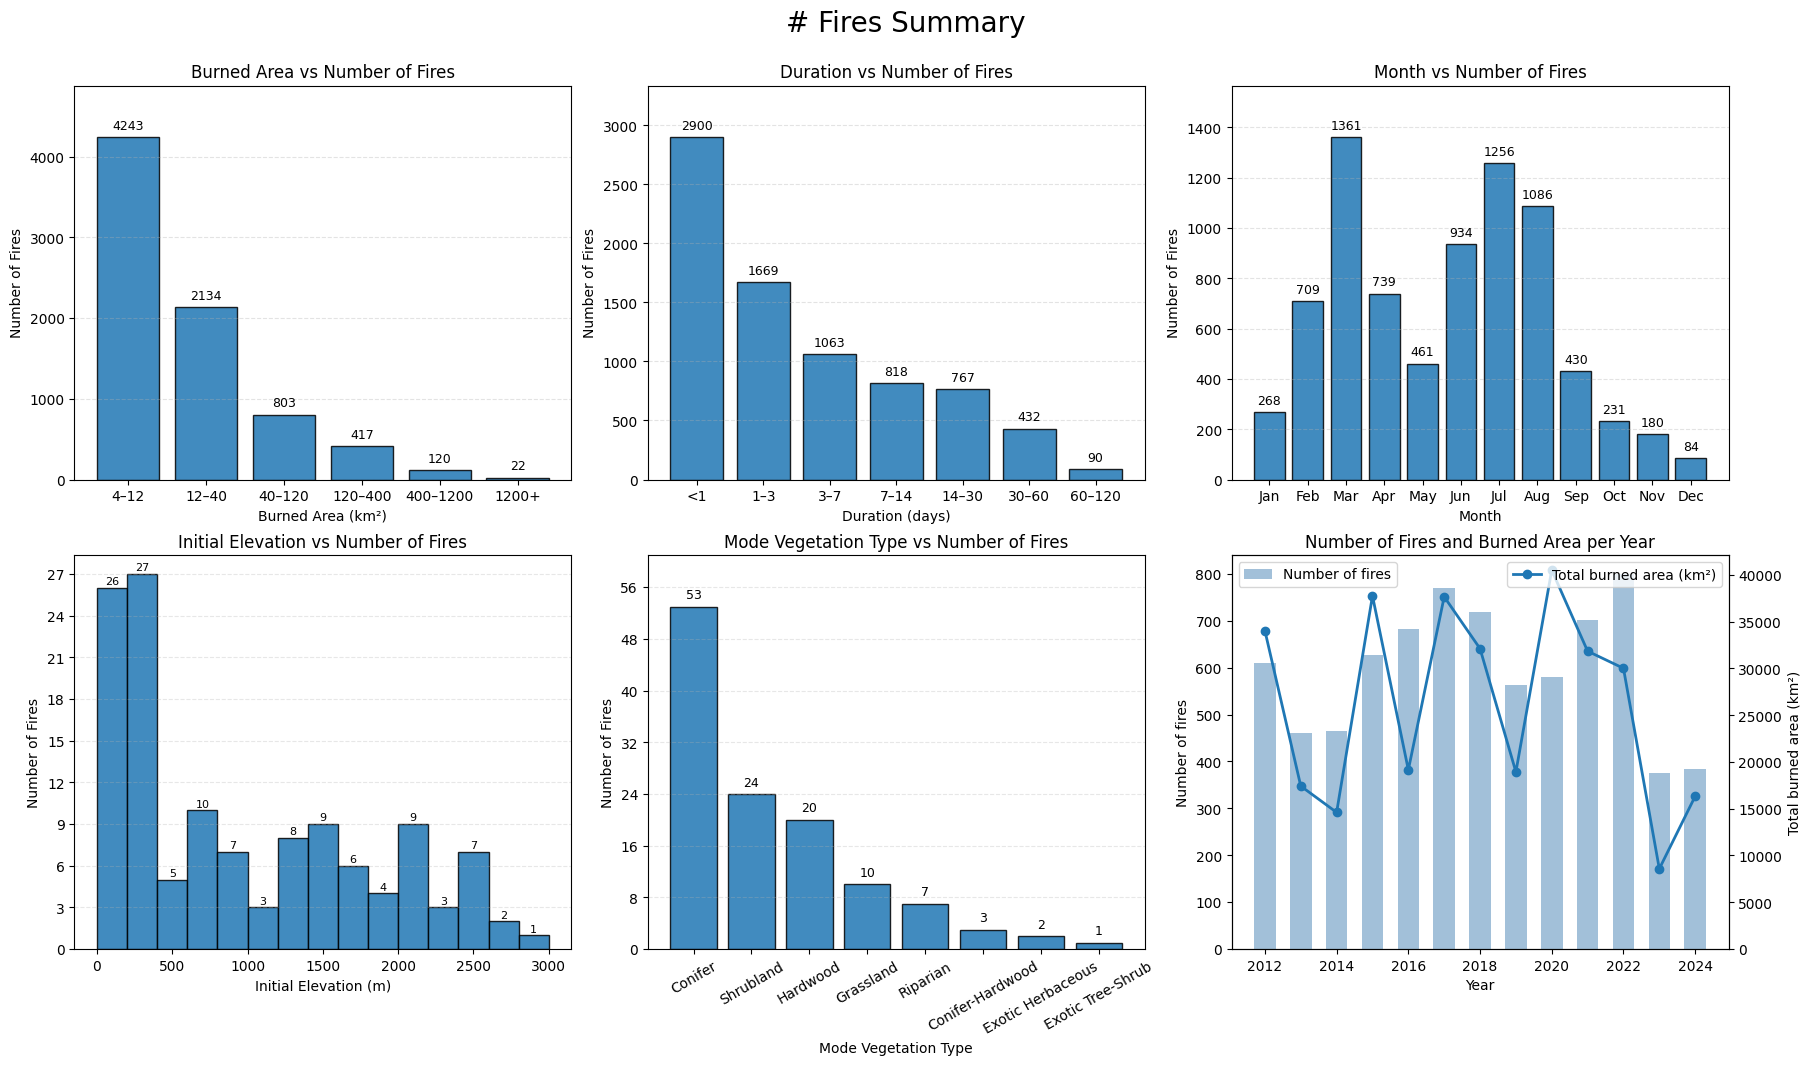

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

firelist_path = "/Users/pc/Desktop/2025/FireCube/FireCube-1/inputData/fireslist2012-2024.csv"
firelist = pd.read_csv(firelist_path)

fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
ax1, ax2, ax3, ax4, ax5, ax6 = axes.ravel()

# 1) Fire size histogram 
TARGET_YEAR = None
data = firelist.copy()
if TARGET_YEAR is not None and "Year" in data.columns:
    data = data[data["Year"] == TARGET_YEAR]

if "BurnBndAc" not in data.columns:
    raise KeyError("Column 'BurnBndAc' not found in firelist for size histogram.")

# acres → km²
sizes_km2 = pd.to_numeric(data["BurnBndAc"], errors="coerce") * 0.00404686
sizes_km2 = sizes_km2.replace([np.inf, -np.inf], np.nan).dropna()
sizes_km2 = sizes_km2[sizes_km2 >= 4]

bins   = [4, 12, 40, 120, 400, 1200, np.inf]
labels = ["4–12", "12–40", "40–120", "120–400", "400–1200", "1200+"]

cats = pd.cut(sizes_km2, bins=bins, labels=labels, right=False, include_lowest=True)
counts = cats.value_counts().reindex(labels, fill_value=0)

bars = ax1.bar(counts.index, counts.values,
               edgecolor="black", alpha=0.85)
ymax = counts.values.max()
ax1.set_ylim(0, ymax * 1.15)

for i, c in enumerate(counts.values):
    ax1.text(i, c + ymax * 0.015, str(int(c)),
             ha='center', va='bottom', fontsize=9)

ax1.set_title("Burned Area vs Number of Fires")
ax1.set_xlabel("Burned Area (km²)")
ax1.set_ylabel("Number of Fires")
ax1.grid(axis="y", linestyle="--", alpha=0.35)

# 2) Duration histogram
if not {"tst", "ted"}.issubset(firelist.columns):
    raise KeyError("Columns 'tst' and 'ted' are required in firelist for duration plot.")

tst_dt = pd.to_datetime(firelist["tst"], errors="coerce")
ted_dt = pd.to_datetime(firelist["ted"], errors="coerce")

# start time default to 1:30 AM
tst_dt = tst_dt.dt.floor("D") + pd.Timedelta(hours=1, minutes=30)

dur_days = (ted_dt - tst_dt).dt.total_seconds() / 86400.0
dur_days = dur_days.replace([np.inf, -np.inf], np.nan).dropna()
dur_days = dur_days[dur_days >= 0]

bins   = [0, 1, 3, 7, 14, 30, 60, 120]
labels = ["<1", "1–3", "3–7", "7–14", "14–30", "30–60", "60–120"]

cats = pd.cut(dur_days, bins=bins, labels=labels, right=False, include_lowest=True)
counts = cats.value_counts().reindex(labels, fill_value=0)

bars = ax2.bar(counts.index, counts.values,
               edgecolor="black", alpha=0.85)

ymax = counts.values.max()
ax2.set_ylim(0, ymax * 1.15)

for i, c in enumerate(counts.values):
    ax2.text(i, c + ymax*0.015, str(int(c)),
             ha='center', va='bottom', fontsize=9)

ax2.set_title("Duration vs Number of Fires")
ax2.set_xlabel("Duration (days)")
ax2.set_ylabel("Number of Fires")
ax2.grid(axis="y", linestyle="--", alpha=0.35)

# 3) Fires per month
tst_dt2 = pd.to_datetime(firelist["tst"], errors="coerce").dropna()
months = tst_dt2.dt.month

counts = months.value_counts().sort_index()
month_labels = [pd.to_datetime(str(m), format='%m').strftime('%b') for m in counts.index]

bars = ax3.bar(month_labels, counts.values,
               edgecolor="black", alpha=0.85)

ymax = counts.values.max()
ax3.set_ylim(0, ymax * 1.15)

for i, c in enumerate(counts.values):
    ax3.text(i, c + ymax * 0.015, str(int(c)),
             ha="center", va="bottom", fontsize=9)

ax3.set_title("Month vs Number of Fires")
ax3.set_xlabel("Month")
ax3.set_ylabel("Number of Fires")
ax3.grid(axis="y", linestyle="--", alpha=0.35)

# 4) Initial elevation histogram 
if "elevations" not in globals():
    raise RuntimeError(
        "Variable 'elevations' not found. "
        "Run plot_initial_elevation_from_cubes(...) first."
    )

custom_bins = np.arange(0, 3200, 200)

counts, bins, patches = ax4.hist(
    elevations,
    bins=custom_bins,
    edgecolor="black",
    alpha=0.85
)

ax4.set_title("Initial Elevation vs Number of Fires")
ax4.set_xlabel("Initial Elevation (m)")
ax4.set_ylabel("Number of Fires")

from matplotlib.ticker import MaxNLocator
ax4.yaxis.set_major_locator(MaxNLocator(integer=True))
ax4.grid(axis="y", linestyle="--", alpha=0.3)

for count, patch in zip(counts, patches):
    if count > 0:
        # center of bar
        x = patch.get_x() + patch.get_width()/2
        y = count
        ax4.text(x, y + 0.1, str(int(count)),
                 ha="center", va="bottom", fontsize=8)


# 5) Mode vegetation type bar char
if "veg_counts" not in globals():
    raise RuntimeError(
        "Variable 'veg_counts' not found. "
        "Run plot_mode_veg_from_cubes(...) first."
    )

from matplotlib.ticker import MaxNLocator

# Bar plot: mode vegetation type vs number of fires
bars = ax5.bar(veg_counts.index, veg_counts.values,
               edgecolor="black", alpha=0.85)

ymax = veg_counts.values.max()
ax5.set_ylim(0, ymax * 1.15)

# Add count labels on top of bars
for i, c in enumerate(veg_counts.values):
    ax5.text(i, c + ymax * 0.015, str(int(c)),
             ha="center", va="bottom", fontsize=9)

ax5.set_title("Mode Vegetation Type vs Number of Fires")
ax5.set_xlabel("Mode Vegetation Type")
ax5.set_ylabel("Number of Fires")
ax5.tick_params(axis="x", rotation=30)
ax5.grid(axis="y", alpha=0.3, linestyle="--")

# Force integer ticks on y-axis
ax5.yaxis.set_major_locator(MaxNLocator(integer=True))


# 6) Number of fires vs burned area per year
area_col = "BurnBndAc"
year_col = "Year"
id_col = "Event_ID"

yearly_stats = (
    firelist
    .groupby(year_col)
    .agg(
        total_burned_area_acres=(area_col, "sum"),
        fire_count=(id_col, "nunique"),
    )
    .reset_index()
    .sort_values(year_col)
)

yearly_stats["total_burned_area_km2"] = (
    yearly_stats["total_burned_area_acres"] * 0.00404686
)

years    = yearly_stats[year_col]
area_km2 = yearly_stats["total_burned_area_km2"]
count    = yearly_stats["fire_count"]

# LEFT AXIS → Number of fires
ax6.bar(
    years, count, alpha=0.5, width=0.6,
    label="Number of fires", color="steelblue"
)
ax6.set_xlabel("Year")
ax6.set_ylabel("Number of fires")
ax6.tick_params(axis="y")

# RIGHT AXIS → Burned area (km²)
ax6b = ax6.twinx()
ax6b.plot(
    years, area_km2,
    marker="o", linewidth=2,
    label="Total burned area (km²)"
)
ax6b.set_ylabel("Total burned area (km²)")
ax6b.tick_params(axis="y")
ax6b.set_ylim(bottom=0)

# Legends
ax6.legend(loc="upper left")
ax6b.legend(loc="upper right")

ax6.set_title("Number of Fires and Burned Area per Year")

fig.suptitle("# Fires Summary", y=1.05, fontsize=20)
plt.show()


/var/folders/53/419gvyh13dzgnkd1zfn_g5jw0000gn/T/ipykernel_5590/899311424.py:81: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(["size_bin", "Incid_Type"]).size()
/var/folders/53/419gvyh13dzgnkd1zfn_g5jw0000gn/T/ipykernel_5590/899311424.py:127: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dur_df.groupby(["dur_bin", "Incid_Type"]).size()


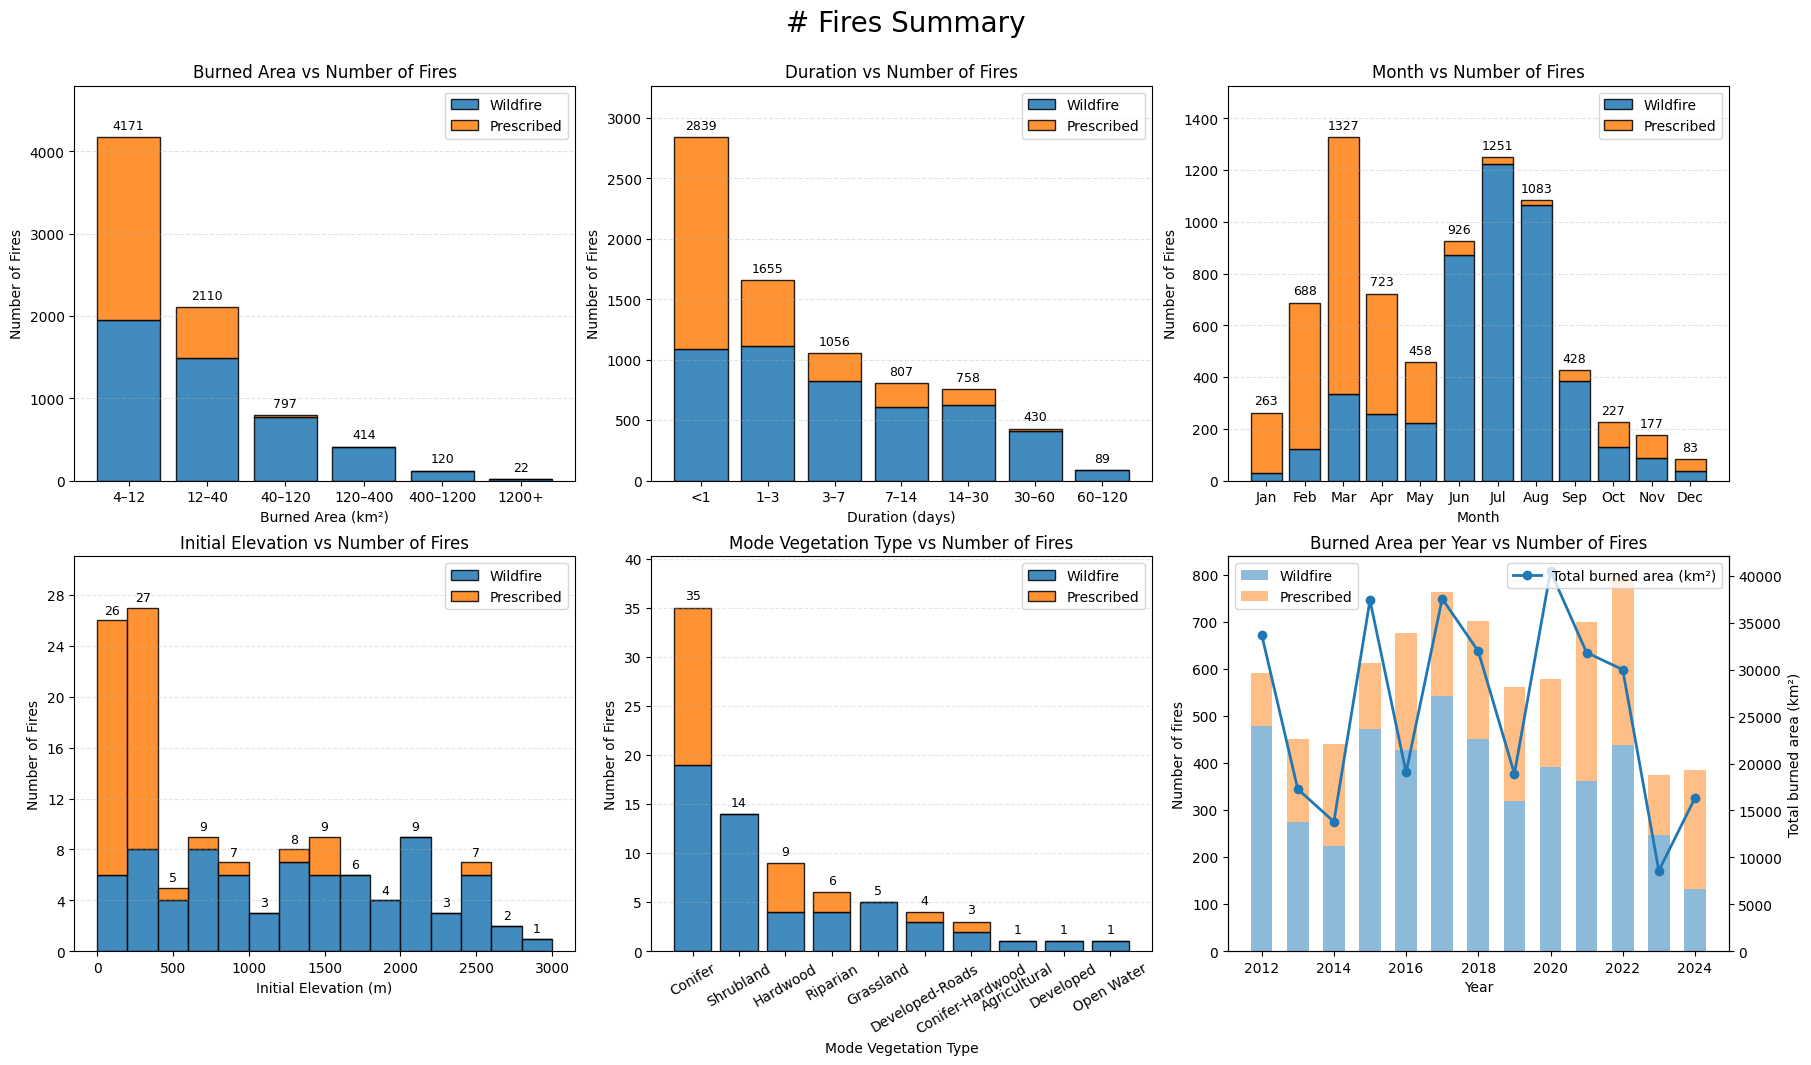

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 0) Load + normalize firelist
firelist_path = "/Users/pc/Desktop/2025/FireCube/FireCube-1/inputData/fireslist2012-2024_withtype.csv"
firelist = pd.read_csv(firelist_path)

if "Incid_Type" not in firelist.columns:
    raise KeyError("Column 'Incid_Type' not found in firelist. Make sure you're using the *_withtype.csv file.")

firelist["Incid_Type"] = (
    firelist["Incid_Type"].astype(str).str.strip()
    .replace({"Prescribed Fire": "Prescribed", "Wildfire": "Wildfire"})
)

TYPE_ORDER  = ["Wildfire", "Prescribed"]
TYPE_COLORS = {"Wildfire": "#1f77b4", "Prescribed": "#ff7f0e"}

firelist = firelist[firelist["Incid_Type"].isin(TYPE_ORDER)].copy()


if "elev_df" not in globals() or elev_df is None or len(elev_df) == 0:
    raise RuntimeError("elev_df is missing/empty. Run plot_initial_elevation_from_cubes(...) first.")

if "veg_df" not in globals() or veg_df is None or len(veg_df) == 0:
    raise RuntimeError("veg_df is missing/empty. Run plot_ignition_veg_from_cubes(...) first.")

# Copy
elev_df = elev_df.copy()
veg_df  = veg_df.copy()

if "Incid_Type" not in elev_df.columns:
    elev_df = elev_df.merge(firelist[["Event_ID", "Incid_Type"]], on="Event_ID", how="inner")

if "Incid_Type" not in veg_df.columns:
    veg_df = veg_df.merge(firelist[["Event_ID", "Incid_Type"]], on="Event_ID", how="inner")

# Normalize types inside these dfs too
elev_df["Incid_Type"] = (
    elev_df["Incid_Type"].astype(str).str.strip()
    .replace({"Prescribed Fire": "Prescribed", "Wildfire": "Wildfire"})
)
veg_df["Incid_Type"] = (
    veg_df["Incid_Type"].astype(str).str.strip()
    .replace({"Prescribed Fire": "Prescribed", "Wildfire": "Wildfire"})
)

elev_df = elev_df[elev_df["Incid_Type"].isin(TYPE_ORDER)].copy()
veg_df  = veg_df[veg_df["Incid_Type"].isin(TYPE_ORDER)].copy()

# 1) Make combined panel
fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
ax1, ax2, ax3, ax4, ax5, ax6 = axes.ravel()

# 1) Burned Area histogram
TARGET_YEAR = None
data = firelist.copy()
if TARGET_YEAR is not None and "Year" in data.columns:
    data = data[data["Year"] == TARGET_YEAR]

sizes_km2 = pd.to_numeric(data["BurnBndAc"], errors="coerce") * 0.00404686
data = data.assign(size_km2=sizes_km2).replace([np.inf, -np.inf], np.nan).dropna(subset=["size_km2"])
data = data[data["size_km2"] >= 4]

bins   = [4, 12, 40, 120, 400, 1200, np.inf]
labels = ["4–12", "12–40", "40–120", "120–400", "400–1200", "1200+"]

data["size_bin"] = pd.cut(data["size_km2"], bins=bins, labels=labels, right=False, include_lowest=True)

counts_by_type = (
    data.groupby(["size_bin", "Incid_Type"]).size()
        .unstack("Incid_Type").reindex(labels).fillna(0)
)
for t in TYPE_ORDER:
    if t not in counts_by_type.columns:
        counts_by_type[t] = 0
counts_by_type = counts_by_type[TYPE_ORDER]

bottom = np.zeros(len(labels))
for t in TYPE_ORDER:
    vals = counts_by_type[t].to_numpy()
    ax1.bar(labels, vals, bottom=bottom, edgecolor="black", alpha=0.85,
            label=t, color=TYPE_COLORS[t])
    bottom += vals

totals = counts_by_type.sum(axis=1).to_numpy()
ymax = totals.max() if len(totals) else 0
ax1.set_ylim(0, ymax * 1.15 if ymax > 0 else 1)
for i, total in enumerate(totals):
    ax1.text(i, total + ymax * 0.015, str(int(total)), ha="center", va="bottom", fontsize=9)

ax1.set_title("Burned Area vs Number of Fires")
ax1.set_xlabel("Burned Area (km²)")
ax1.set_ylabel("Number of Fires")
ax1.grid(axis="y", linestyle="--", alpha=0.35)
ax1.legend()

# 2) Duration histogram
tst_dt = pd.to_datetime(firelist["tst"], errors="coerce")
ted_dt = pd.to_datetime(firelist["ted"], errors="coerce")
tst_dt = tst_dt.dt.floor("D") + pd.Timedelta(hours=1, minutes=30)

dur_days = (ted_dt - tst_dt).dt.total_seconds() / 86400.0
dur_df = firelist.copy()
dur_df["dur_days"] = dur_days
dur_df = dur_df.replace([np.inf, -np.inf], np.nan).dropna(subset=["dur_days"])
dur_df = dur_df[dur_df["dur_days"] >= 0]

bins   = [0, 1, 3, 7, 14, 30, 60, 120]
labels = ["<1", "1–3", "3–7", "7–14", "14–30", "30–60", "60–120"]

dur_df["dur_bin"] = pd.cut(dur_df["dur_days"], bins=bins, labels=labels, right=False, include_lowest=True)

counts_by_type = (
    dur_df.groupby(["dur_bin", "Incid_Type"]).size()
          .unstack("Incid_Type").reindex(labels).fillna(0)
)
for t in TYPE_ORDER:
    if t not in counts_by_type.columns:
        counts_by_type[t] = 0
counts_by_type = counts_by_type[TYPE_ORDER]

bottom = np.zeros(len(labels))
for t in TYPE_ORDER:
    vals = counts_by_type[t].to_numpy()
    ax2.bar(labels, vals, bottom=bottom, edgecolor="black", alpha=0.85,
            label=t, color=TYPE_COLORS[t])
    bottom += vals

totals = counts_by_type.sum(axis=1).to_numpy()
ymax = totals.max() if len(totals) else 0
ax2.set_ylim(0, ymax * 1.15 if ymax > 0 else 1)
for i, total in enumerate(totals):
    ax2.text(i, total + ymax * 0.015, str(int(total)), ha="center", va="bottom", fontsize=9)

ax2.set_title("Duration vs Number of Fires")
ax2.set_xlabel("Duration (days)")
ax2.set_ylabel("Number of Fires")
ax2.grid(axis="y", linestyle="--", alpha=0.35)
ax2.legend()

# 3) Fires per month
tst_dt2 = pd.to_datetime(firelist["tst"], errors="coerce")
month_df = firelist.copy()
month_df["month"] = tst_dt2.dt.month
month_df = month_df.dropna(subset=["month"])
month_df["month"] = month_df["month"].astype(int)

counts_by_type = (
    month_df.groupby(["month", "Incid_Type"]).size()
            .unstack("Incid_Type").reindex(range(1, 13), fill_value=0)
)
for t in TYPE_ORDER:
    if t not in counts_by_type.columns:
        counts_by_type[t] = 0
counts_by_type = counts_by_type[TYPE_ORDER]

month_labels = [pd.to_datetime(str(m), format="%m").strftime("%b") for m in range(1, 13)]

bottom = np.zeros(12)
for t in TYPE_ORDER:
    vals = counts_by_type[t].to_numpy()
    ax3.bar(month_labels, vals, bottom=bottom, edgecolor="black", alpha=0.85,
            label=t, color=TYPE_COLORS[t])
    bottom += vals

totals = counts_by_type.sum(axis=1).to_numpy()
ymax = totals.max() if len(totals) else 0
ax3.set_ylim(0, ymax * 1.15 if ymax > 0 else 1)
for i, total in enumerate(totals):
    ax3.text(i, total + ymax * 0.015, str(int(total)), ha="center", va="bottom", fontsize=9)

ax3.set_title("Month vs Number of Fires")
ax3.set_xlabel("Month")
ax3.set_ylabel("Number of Fires")
ax3.grid(axis="y", linestyle="--", alpha=0.35)
ax3.legend()

# 4) Initial elevation histogram
if "elev_df" not in globals() or elev_df is None or len(elev_df) == 0:
    raise RuntimeError("elev_df is missing/empty. Run plot_initial_elevation_from_cubes(...) first.")

elev_plot_df = elev_df.copy()

elev_plot_df["Incid_Type"] = (
    elev_plot_df["Incid_Type"].astype(str).str.strip()
    .replace({"Prescribed Fire": "Prescribed", "Wildfire": "Wildfire"})
)

# keep only your 2 types
elev_plot_df = elev_plot_df[elev_plot_df["Incid_Type"].isin(TYPE_ORDER)].copy()

# numeric elevation
elev_plot_df["elevation"] = pd.to_numeric(elev_plot_df["elevation"], errors="coerce")
elev_plot_df = elev_plot_df.dropna(subset=["elevation"])

custom_bins = np.arange(0, 3200, 200)

# split by type
w = elev_plot_df.loc[elev_plot_df["Incid_Type"] == TYPE_ORDER[0], "elevation"].to_numpy()
p = elev_plot_df.loc[elev_plot_df["Incid_Type"] == TYPE_ORDER[1], "elevation"].to_numpy()

# explicit histograms
w_counts, bin_edges = np.histogram(w, bins=custom_bins)
p_counts, _         = np.histogram(p, bins=custom_bins)

bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_widths  = np.diff(bin_edges)

totals = w_counts + p_counts
ymax = totals.max() if len(totals) else 0

# clear axis in case it had old plot
ax4.cla()

# stacked bars
ax4.bar(
    bin_centers,
    w_counts,
    width=bin_widths,
    edgecolor="black",
    alpha=0.85,
    color=TYPE_COLORS[TYPE_ORDER[0]],
    label=TYPE_ORDER[0],
    align="center",
)
ax4.bar(
    bin_centers,
    p_counts,
    width=bin_widths,
    bottom=w_counts,
    edgecolor="black",
    alpha=0.85,
    color=TYPE_COLORS[TYPE_ORDER[1]],
    label=TYPE_ORDER[1],
    align="center",
)

# total labels on top of each stacked bar (bring closer by reducing offset factor)
label_offset = ymax * 0.01
for x, total in zip(bin_centers, totals):
    if total > 0:
        ax4.text(
            x,
            total + label_offset,
            str(int(total)),
            ha="center",
            va="bottom",
            fontsize=9,
        )

# cosmetics
ax4.set_title("Initial Elevation vs Number of Fires")
ax4.set_xlabel("Initial Elevation (m)")
ax4.set_ylabel("Number of Fires")
ax4.grid(axis="y", linestyle="--", alpha=0.3)
ax4.yaxis.set_major_locator(MaxNLocator(integer=True))
ax4.set_ylim(0, ymax * 1.15 if ymax > 0 else 1)
ax4.legend()

# 5) Vegetation
veg_plot_df = veg_df.copy()

veg_counts_by_type = (
    veg_plot_df.groupby(["veg_type", "Incid_Type"]).size()
               .unstack("Incid_Type").fillna(0)
)
for t in TYPE_ORDER:
    if t not in veg_counts_by_type.columns:
        veg_counts_by_type[t] = 0
veg_counts_by_type = veg_counts_by_type[TYPE_ORDER]
veg_counts_by_type = veg_counts_by_type.loc[
    veg_counts_by_type.sum(axis=1).sort_values(ascending=False).index
]

bottom = np.zeros(len(veg_counts_by_type.index))
for t in TYPE_ORDER:
    vals = veg_counts_by_type[t].to_numpy()
    ax5.bar(
        veg_counts_by_type.index, vals,
        bottom=bottom, edgecolor="black", alpha=0.85,
        label=t, color=TYPE_COLORS[t]
    )
    bottom += vals

totals = veg_counts_by_type.sum(axis=1).to_numpy()
ymax = totals.max() if len(totals) else 0
ax5.set_ylim(0, ymax * 1.15 if ymax > 0 else 1)
for i, total in enumerate(totals):
    ax5.text(i, total + ymax * 0.015, str(int(total)), ha="center", va="bottom", fontsize=9)

ax5.set_title("Mode Vegetation Type vs Number of Fires")
ax5.set_xlabel("Mode Vegetation Type")
ax5.set_ylabel("Number of Fires")
ax5.tick_params(axis="x", rotation=30)
ax5.grid(axis="y", alpha=0.3, linestyle="--")
ax5.legend()

# 6) Number of fires per year
area_col = "BurnBndAc"
year_col = "Year"
id_col = "Event_ID"

year_type_counts = (
    firelist.groupby([year_col, "Incid_Type"])[id_col].nunique()
            .unstack("Incid_Type").fillna(0).sort_index()
)
for t in TYPE_ORDER:
    if t not in year_type_counts.columns:
        year_type_counts[t] = 0
year_type_counts = year_type_counts[TYPE_ORDER]

year_total_area_km2 = (
    firelist.groupby(year_col)[area_col].sum().sort_index().astype(float) * 0.00404686
)

years = year_type_counts.index.to_numpy()

bottom = np.zeros(len(years))
for t in TYPE_ORDER:
    vals = year_type_counts[t].to_numpy()
    ax6.bar(years, vals, bottom=bottom, alpha=0.5, width=0.6,
            label=t, color=TYPE_COLORS[t])
    bottom += vals

ax6.set_xlabel("Year")
ax6.set_ylabel("Number of fires")
ax6.set_title("Burned Area per Year vs Number of Fires")

ax6b = ax6.twinx()
ax6b.plot(year_total_area_km2.index.to_numpy(), year_total_area_km2.to_numpy(),
          marker="o", linewidth=2, label="Total burned area (km²)")
ax6b.set_ylabel("Total burned area (km²)")
ax6b.set_ylim(bottom=0)

ax6.legend(loc="upper left")
ax6b.legend(loc="upper right")

fig.suptitle("# Fires Summary", y=1.05, fontsize=20)
plt.show()


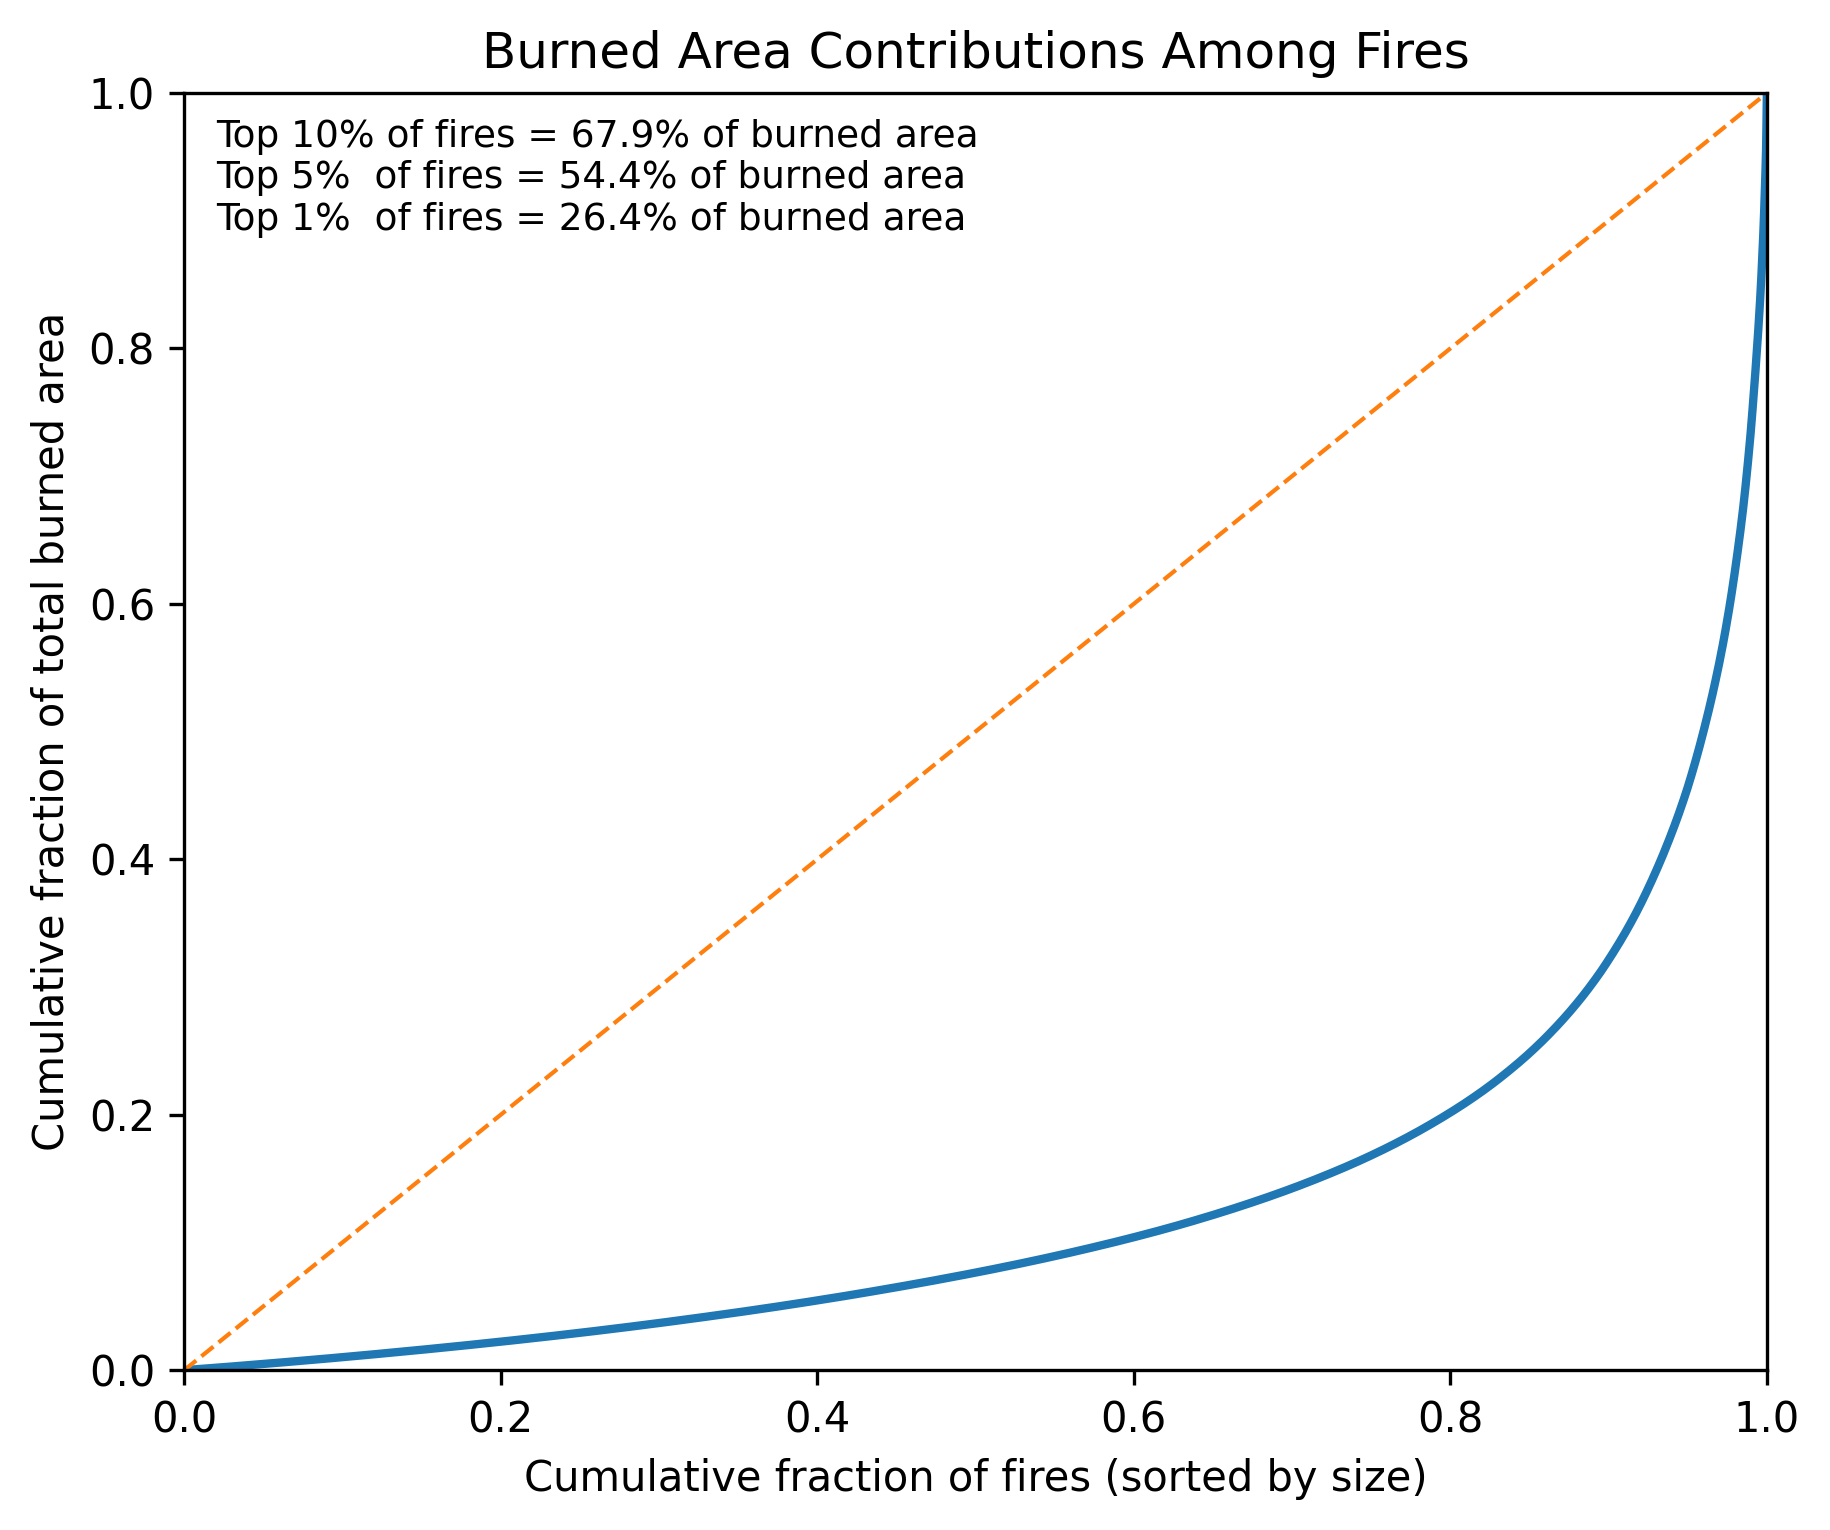

{'top10_area_share': 0.6787392984107483, 'top05_area_share': 0.5436034210506961, 'top01_area_share': 0.2635256950379357}


In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def figure1_lorenz_burned_area(
    firelist: pd.DataFrame,
    area_col: str = "BurnBndAc",
    to_km2: bool = True,
    title: str = "Burned Area Contributions Among Fires",
):
    area = pd.to_numeric(firelist[area_col], errors="coerce").dropna()
    area = area[area > 0]  # drop zero/negative

    if to_km2:
        area = area * 0.0040468564224

    a = np.sort(area.to_numpy())
    cum_area = np.cumsum(a) / np.sum(a)
    cum_fires = np.arange(1, len(a) + 1) / len(a)

    # prepend 0 so curve starts at origin
    cum_area = np.insert(cum_area, 0, 0.0)
    cum_fires = np.insert(cum_fires, 0, 0.0)

    def top_fraction_contributes(top_frac):
        n = len(a)
        k = int(np.ceil(top_frac * n))
        top_share = a[-k:].sum() / a.sum()
        return top_share

    top10 = top_fraction_contributes(0.10)
    top05 = top_fraction_contributes(0.05)
    top01 = top_fraction_contributes(0.01)

    fig, ax = plt.subplots(figsize=(6.2, 5.2), dpi=300)
    ax.plot(cum_fires, cum_area, linewidth=2)
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)  # equality line

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Cumulative fraction of fires (sorted by size)")
    ax.set_ylabel("Cumulative fraction of total burned area")
    ax.set_title(title)

    ax.text(
        0.02, 0.98,
        f"Top 10% of fires = {top10*100:.1f}% of burned area\n"
        f"Top 5%  of fires = {top05*100:.1f}% of burned area\n"
        f"Top 1%  of fires = {top01*100:.1f}% of burned area",
        transform=ax.transAxes,
        va="top",
        fontsize=9
    )

    plt.tight_layout()
    return fig, ax, {"top10_area_share": top10, "top05_area_share": top05, "top01_area_share": top01}

firelist = pd.read_csv("/Users/pc/Desktop/2025/FireCube/FireCube-1/inputData/fireslist2012-2024.csv")
fig, ax, stats = figure1_lorenz_burned_area(firelist, area_col="BurnBndAc", to_km2=True)
plt.show()
print(stats)


In [ ]:
import numpy as np
import pandas as pd

def top_fraction_table_rows(
    firelist,
    area_col="BurnBndAc",
    start_col="tst",
    end_col="ted",
    to_km2=True,
    top_fracs=(0.01, 0.05, 0.10, 0.50)
):

    df = firelist.copy()

    df[start_col] = pd.to_datetime(df[start_col])
    df[end_col]   = pd.to_datetime(df[end_col])

    duration_hours = (df[end_col] - df[start_col]).dt.total_seconds() / 3600
    df["duration_days"] = duration_hours / 24

    df[area_col] = pd.to_numeric(df[area_col], errors="coerce")
    if to_km2:
        df["area_km2"] = df[area_col] * 0.0040468564224
    else:
        df["area_km2"] = df[area_col]

    df = df.dropna(subset=["area_km2", "duration_days"])
    df = df[(df["area_km2"] > 0) & (df["duration_days"] > 0)]

    df["spread_rate"] = df["area_km2"] / df["duration_days"]  # km²/day

    # sort by burned area (largest first)
    df = df.sort_values("area_km2", ascending=False).reset_index(drop=True)

    totals = {
        "area": df["area_km2"].sum(),
        "dur": df["duration_days"].sum(),
        "spread": df["spread_rate"].sum()
    }

    rows = []
    n = len(df)

    for frac in top_fracs:
        k = int(np.ceil(frac * n))
        top = df.iloc[:k]

        rows.append([
            f"Top {int(frac*100)}%",
            100 * top["duration_days"].sum() / totals["dur"],
            100 * top["area_km2"].sum() / totals["area"],
            100 * top["spread_rate"].sum() / totals["spread"]
        ])

    table = pd.DataFrame(
        rows,
        columns=[
            "Top % of fires",
            "% of total duration",
            "% of total burned area",
            "% of total spread activity"
        ]
    ).set_index("Top % of fires").round(2)

    return table


In [13]:
firelist = pd.read_csv("/Users/pc/Desktop/2025/FireCube/FireCube-1/inputData/fireslist2012-2024_withtype.csv")

tbl = top_fraction_table_rows(firelist)

print(tbl)


                % of total duration  % of total burned area  \
Top % of fires                                                
Top 1%                         4.42                   26.35   
Top 5%                        16.82                   54.36   
Top 10%                       29.58                   67.87   
Top 50%                       75.74                   92.36   

                % of total spread activity  
Top % of fires                              
Top 1%                                7.10  
Top 5%                               18.16  
Top 10%                              29.50  
Top 50%                              72.42  
